# 03 Architectural Redistribution: The Distal Shift

We found that HI genes redistribute regulatory control from promoters to distal regions.

**The Story So Far: **
- HI promoters have MORE variants but LESS noise (buffered promoters)
- Per-variant effects are dampened by ~22%

Now we want to ask where does the regulatory control GO?

**Answer:** Distally. HI genes show a 2.5-fold higher distal-to-core regulatory ratio.

From this nb we take to abstract
1. "HI genes show 2.5-fold enrichment of regulatory activity in distal regions (2-10kb from gene start)"
2. "ENCODE data independently confirmed this: HI genes have significantly more enhancers (28 vs 24 per gene, P<10⁻⁶)"

**Key Metrics:**
- Spatial variance: `vg_promoter_core`, `vg_proximal_upstream`, `vg_distal_upstream`
- Distal:Core ratio = (vg_distal_upstream + vg_down_distal) / vg_promoter_core
- ENCODE: `num_enh` (enhancer count per gene)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [2]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '03_Architectural_Redistribution'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [3]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

# Split by group
df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes



## 3.1 Define Spatial Regions

**Region definitions (relative to TSS):**
- **Promoter Core:** TSS ± 200bp
- **Proximal Upstream:** -2kb to -2kb
- **Distal Upstream:** -2kb to -10kb
- **Proximal Downstream:** +2kb to +2kb
- **Distal Downstream:** +2kb to +10kb

**Distal = distal_upstream + distal_downstream**

In [4]:
print('''
 Region Layout

    -10kb         -2kb    -200bp  TSS  +200bp      +2kb         +10kb
      |____________|________|______|______|_________|____________|
      |   Distal   |Proximal|  Core|      |Proximal |   Distal   |
      | Upstream   |Upstream|  Promoter   |Downstrm | Downstream |
      | (Enhancers)|(Reg)   |  (Pol II)   |(5'UTR)  | (Gene Body)|

    [-10k, -2k]  [-2k, -200] [-200, +200] [+200, +2k] [+2k, +10k]

Columns:
  - vg_distal_upstream:    Variance in -10kb to -2kb    (8kb window)
  - vg_proximal_upstream:  Variance in -2kb to -200bp   (1.8kb window)
  - vg_promoter_core:      Variance in -200bp to +200bp (400bp window) ← CORE
  - vg_down_proximal:      Variance in +200bp to +2kb   (1.8kb window)
  - vg_down_distal:        Variance in +2kb to +10kb    (8kb window)

For the Upstream Diagnostic:
  DIAGNOSTIC WINDOW: vg_proximal_upstream (-2kb to -200bp)
  REFERENCE WINDOW:  vg_promoter_core (-200bp to +200bp)
''')


 Region Layout

    -10kb         -2kb    -200bp  TSS  +200bp      +2kb         +10kb
      |____________|________|______|______|_________|____________|
      |   Distal   |Proximal|  Core|      |Proximal |   Distal   |
      | Upstream   |Upstream|  Promoter   |Downstrm | Downstream |
      | (Enhancers)|(Reg)   |  (Pol II)   |(5'UTR)  | (Gene Body)|

    [-10k, -2k]  [-2k, -200] [-200, +200] [+200, +2k] [+2k, +10k]

Columns:
  - vg_distal_upstream:    Variance in -10kb to -2kb    (8kb window)
  - vg_proximal_upstream:  Variance in -2kb to -200bp   (1.8kb window)
  - vg_promoter_core:      Variance in -200bp to +200bp (400bp window) ← CORE
  - vg_down_proximal:      Variance in +200bp to +2kb   (1.8kb window)
  - vg_down_distal:        Variance in +2kb to +10kb    (8kb window)

For the Upstream Diagnostic:
  DIAGNOSTIC WINDOW: vg_proximal_upstream (-2kb to -200bp)
  REFERENCE WINDOW:  vg_promoter_core (-200bp to +200bp)



In [5]:
spatial_cols = ['vg_promoter_core', 'vg_proximal_upstream', 'vg_distal_upstream',
                'vg_down_proximal', 'vg_down_distal']

## 3.2 Calculate Distal-to-Core Ratio

 Calculate both Physical (Count) and Functional (Variance) ratios.
Returns two numpy arrays: (functional_ratio, physical_ratio)

**Key metric:** Distal:Core Ratio = (vg_distal_upstream + vg_down_distal) / vg_promoter_core

**New metric:** Distal share of total vg = (vg_distal_upstream + vg_down_distal) / (vg_promoter_core + vg_proximal_upstream + vg_distal_upstream + vg_down_proximal + vg_down_distal)

- Ratio > 1: More regulatory variance in distal regions than promoter
- Ratio < 1: More regulatory variance concentrated in promoter
- Distal share is also reported separately for upstream and downstream


In [6]:
def calculate_dual_ratios(df, is_synth=False):
    suffix = '_perm' if is_synth else ''

    vg_core = df[f'vg_promoter_core{suffix}'].to_numpy()
    vg_distal_upstream = df[f'vg_distal_upstream{suffix}'].to_numpy()
    vg_down_distal = df[f'vg_down_distal{suffix}'].to_numpy()
    
    # Use the pre-calculated total column instead of manual summing
    vg_total = df[f'vg_predicted{suffix}'].to_numpy()

    vg_distal_total = vg_distal_upstream + vg_down_distal
    
    # Avoid division by zero
    vg_core_safe = np.where(vg_core == 0, 1e-10, vg_core)
    vg_total_safe = np.where(vg_total == 0, 1e-10, vg_total)

    functional_ratio = vg_distal_total / vg_core_safe
    distal_share_total = vg_distal_total / vg_total_safe
    distal_upstream_share = vg_distal_upstream / vg_total_safe
    distal_downstream_share = vg_down_distal / vg_total_safe

    n_core = df[f'n_variants_promoter_core{suffix}'].to_numpy()
    n_distal = df[f'n_variants_distal_upstream{suffix}'].to_numpy()
    n_core_safe = np.where(n_core == 0, 1, n_core)
    physical_ratio = n_distal / n_core_safe

    return (
        functional_ratio,
        physical_ratio,
        distal_share_total,
        distal_upstream_share,
        distal_downstream_share,
    )

print(
    f'{"METRIC":<20} | {"HI MEDIAN":<10} | {"BG MEDIAN":<10} | '
    f'{"FOLD":<6} | {"P-VALUE":<10}'
)
print('-' * 70)

(
    hi_func,
    hi_phys,
    hi_distal_share,
    hi_distal_up_share,
    hi_distal_down_share,
) = calculate_dual_ratios(df_hi)
(
    bg_func,
    bg_phys,
    bg_distal_share,
    bg_distal_up_share,
    bg_distal_down_share,
) = calculate_dual_ratios(df_bg)

# functional stats
f_fold = np.median(hi_func) / np.median(bg_func)
_, f_pval = stats.mannwhitneyu(hi_func, bg_func, alternative='greater')
print(
    f'{"Functional (Vg)":<20} | {np.median(hi_func):<10.2f} | '
    f'{np.median(bg_func):<10.2f} | {f_fold:<6.2f} | {f_pval:.2e}'
)

# physical stats
p_fold = np.median(hi_phys) / np.median(bg_phys)
_, p_pval = stats.mannwhitneyu(hi_phys, bg_phys, alternative='greater')
print(
    f'{"Physical (Count)":<20} | {np.median(hi_phys):<10.2f} | '
    f'{np.median(bg_phys):<10.2f} | {p_fold:<6.2f} | {p_pval:.2e}'
)

# distal share stats
d_fold = np.median(hi_distal_share) / np.median(bg_distal_share)
_, d_pval = stats.mannwhitneyu(hi_distal_share, bg_distal_share, alternative='greater')
print(
    f'{"Distal share (Vg)":<20} | {np.median(hi_distal_share):<10.2f} | '
    f'{np.median(bg_distal_share):<10.2f} | {d_fold:<6.2f} | {d_pval:.2e}'
)

# distal share by side
du_fold = np.median(hi_distal_up_share) / np.median(bg_distal_up_share)
_, du_pval = stats.mannwhitneyu(
    hi_distal_up_share,
    bg_distal_up_share,
    alternative='greater',
)
print(
    f'{"Upstream share":<20} | {np.median(hi_distal_up_share):<10.2f} | '
    f'{np.median(bg_distal_up_share):<10.2f} | {du_fold:<6.2f} | {du_pval:.2e}'
)

dd_fold = np.median(hi_distal_down_share) / np.median(bg_distal_down_share)
_, dd_pval = stats.mannwhitneyu(
    hi_distal_down_share,
    bg_distal_down_share,
    alternative='greater',
)
print(
    f'{"Downstream share":<20} | {np.median(hi_distal_down_share):<10.2f} | '
    f'{np.median(bg_distal_down_share):<10.2f} | {dd_fold:<6.2f} | {dd_pval:.2e}'
)

if f_pval < 0.05 and p_pval > 0.05:
    print("\nINTERPRETATION: Strong 'Distal Bias'.")
elif f_pval < 0.05 and p_pval < 0.05:
    print("\nINTERPRETATION: Concordant Signal.")
    print("HI genes have both more distal variants AND higher distal impact.")
else:
    print("\nINTERPRETATION: No significant redistribution observed.")

METRIC               | HI MEDIAN  | BG MEDIAN  | FOLD   | P-VALUE   
----------------------------------------------------------------------
Functional (Vg)      | 28.25      | 12.01      | 2.35   | 1.55e-07
Physical (Count)     | 13.08      | 13.85      | 0.94   | 9.60e-01
Distal share (Vg)    | 0.66       | 0.57       | 1.16   | 8.17e-03
Upstream share       | 0.15       | 0.07       | 2.27   | 6.54e-07
Downstream share     | 0.25       | 0.28       | 0.92   | 3.14e-01

INTERPRETATION: Strong 'Distal Bias'.


In [7]:
def calculate_upstream_share(df, is_synth=False):
    suffix = '_perm' if is_synth else ''
    
    vg_distal_up = df[f'vg_distal_upstream{suffix}'].to_numpy()
    vg_total = df[f'vg_predicted{suffix}'].to_numpy()
    
    # Avoid division by zero
    vg_total_safe = np.where(vg_total == 0, 1e-10, vg_total)
    
    # Calculate Distal Upstream / Total Ratio
    return vg_distal_up / vg_total_safe

# --- Run Calculation ---
hi_share = calculate_upstream_share(df_hi)
bg_share = calculate_upstream_share(df_bg)

fold = np.median(hi_share) / np.median(bg_share)
_, pval = stats.mannwhitneyu(hi_share, bg_share, alternative='greater')

print(f"Distal Upstream Share (Vg_distal_up / Vg_total):")
print(f"HI Median: {np.median(hi_share):.4f} ({np.median(hi_share)*100:.1f}%)")
print(f"BG Median: {np.median(bg_share):.4f} ({np.median(bg_share)*100:.1f}%)")
print(f"Fold Change: {fold:.2f}")
print(f"P-value: {pval:.2e}")

Distal Upstream Share (Vg_distal_up / Vg_total):
HI Median: 0.1542 (15.4%)
BG Median: 0.0680 (6.8%)
Fold Change: 2.27
P-value: 6.54e-07


In [8]:
def calculate_proximal_stats(df, is_synth=False):
    suffix = '_perm' if is_synth else ''
    
    vg_prox_up = df[f'vg_proximal_upstream{suffix}'].to_numpy()
    vg_core = df[f'vg_promoter_core{suffix}'].to_numpy()
    vg_total = df[f'vg_predicted{suffix}'].to_numpy()
    
    # Avoid division by zero
    vg_core_safe = np.where(vg_core == 0, 1e-10, vg_core)
    vg_total_safe = np.where(vg_total == 0, 1e-10, vg_total)
    
    # Calculate Ratios
    ratio_to_core = vg_prox_up / vg_core_safe
    share_of_total = vg_prox_up / vg_total_safe
    
    return ratio_to_core, share_of_total

# --- Run Calculation ---
hi_prox_ratio, hi_prox_share = calculate_proximal_stats(df_hi)
bg_prox_ratio, bg_prox_share = calculate_proximal_stats(df_bg)

# 1. Proximal Upstream / Core Ratio
fold_ratio = np.median(hi_prox_ratio) / np.median(bg_prox_ratio)
_, pval_ratio = stats.mannwhitneyu(hi_prox_ratio, bg_prox_ratio, alternative='greater')

print(f"Proximal Upstream / Core Ratio:")
print(f"HI Median: {np.median(hi_prox_ratio):.2f}")
print(f"BG Median: {np.median(bg_prox_ratio):.2f}")
print(f"Fold Change: {fold_ratio:.2f}")
print(f"P-value: {pval_ratio:.2e}")

print("-" * 40)

# 2. Proximal Upstream Share (Vg_prox_up / Vg_total)
fold_share = np.median(hi_prox_share) / np.median(bg_prox_share)
_, pval_share = stats.mannwhitneyu(hi_prox_share, bg_prox_share, alternative='greater')

print(f"Proximal Upstream Share (Vg_prox_up / Vg_total):")
print(f"HI Median: {np.median(hi_prox_share):.4f} ({np.median(hi_prox_share)*100:.1f}%)")
print(f"BG Median: {np.median(bg_prox_share):.4f} ({np.median(bg_prox_share)*100:.1f}%)")
print(f"Fold Change: {fold_share:.2f}")
print(f"P-value: {pval_share:.2e}")

Proximal Upstream / Core Ratio:
HI Median: 1.41
BG Median: 0.38
Fold Change: 3.69
P-value: 5.67e-12
----------------------------------------
Proximal Upstream Share (Vg_prox_up / Vg_total):
HI Median: 0.0289 (2.9%)
BG Median: 0.0148 (1.5%)
Fold Change: 1.95
P-value: 3.02e-06


Strong 'Distal Bias'.
Mutations are physically spread evenly (Physical p > 0.05),
but the functional impact is selectively shifted to distal regions (Functional p < 0.05).

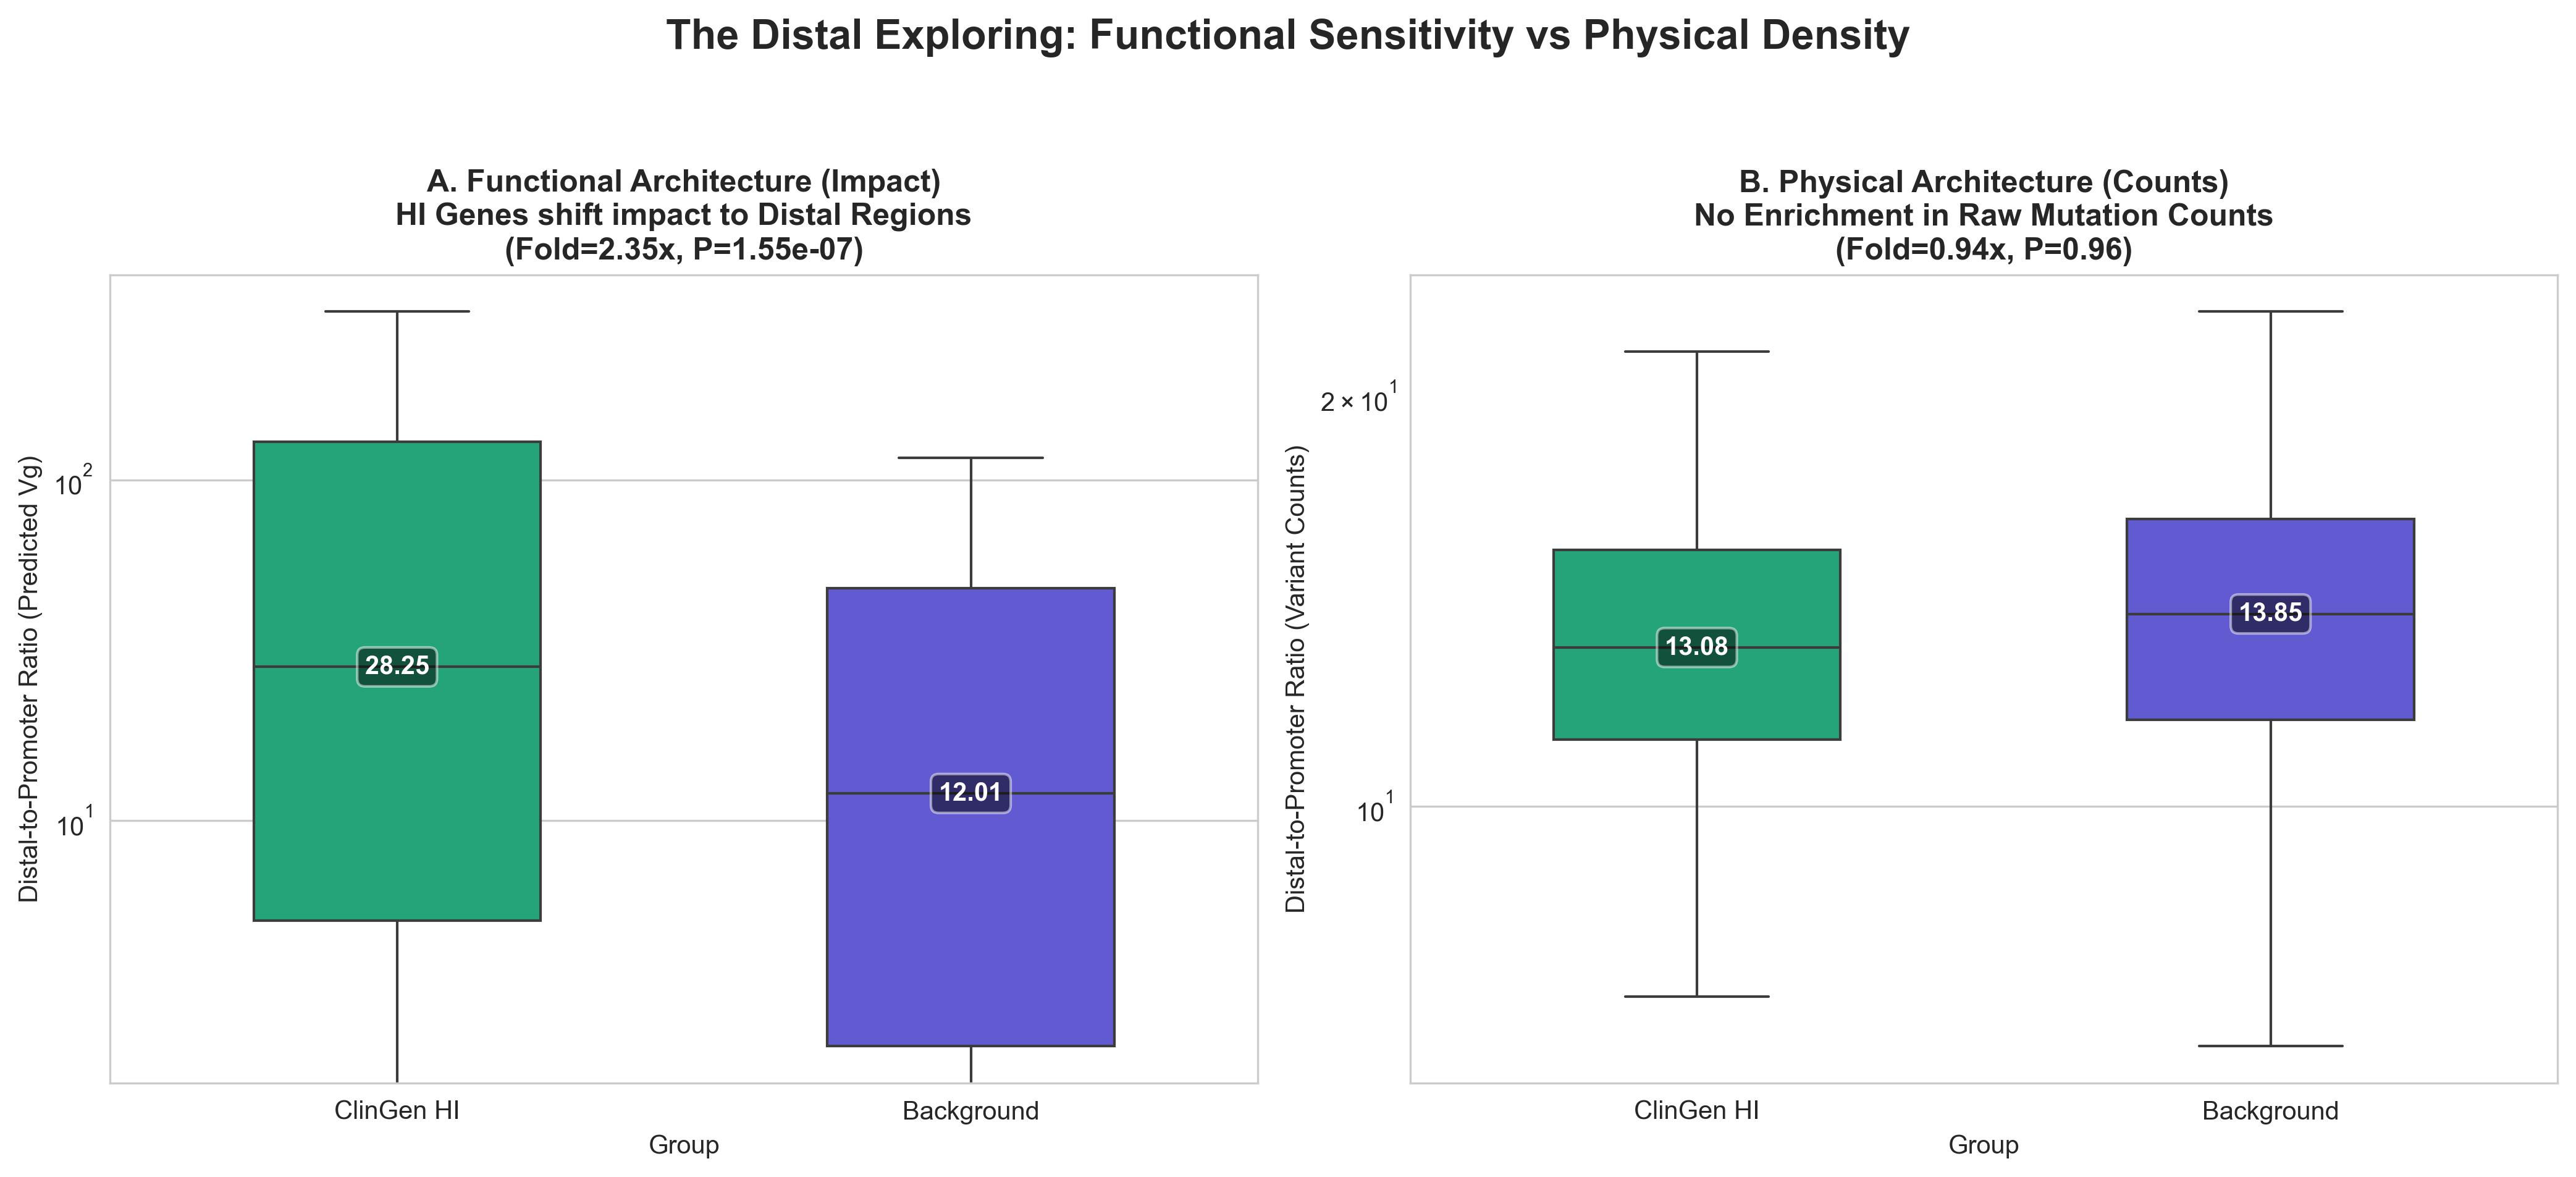

[save_plot] Saved: Final_Submission_3.2_Distal_Core_Ratio_Comparison_20022026_1232.pdf
[save_plot] Saved: Final_Submission_3.2_Distal_Core_Ratio_Comparison_20022026_1232.svg


<Figure size 1920x1440 with 0 Axes>

In [9]:
data_func = pd.DataFrame({
    'Ratio': np.concatenate([hi_func, bg_func]),
    'Group': ['ClinGen HI'] * len(hi_func) + ['Background'] * len(bg_func),
    'Type': 'Functional (Vg)'
})

data_phys = pd.DataFrame({
    'Ratio': np.concatenate([hi_phys, bg_phys]),
    'Group': ['ClinGen HI'] * len(hi_phys) + ['Background'] * len(bg_phys),
    'Type': 'Physical (Counts)'
})

f_stat, f_pval = stats.mannwhitneyu(hi_func, bg_func, alternative='greater')
f_fold = np.median(hi_func) / np.median(bg_func)

# Physical
p_stat, p_pval = stats.mannwhitneyu(hi_phys, bg_phys, alternative='greater')
p_fold = np.median(hi_phys) / np.median(bg_phys)

with autosave('3.2_Distal_Core_Ratio_Comparison', notebook='Final_Submission'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    sns.boxplot(
        data=data_func, x='Group', y='Ratio', ax=ax,
        palette=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']],
        hue='Group', legend=False, showfliers=False, width=0.5
    )

    ax.set_yscale('log')
    ax.set_ylabel('Distal-to-Promoter Ratio (Predicted Vg)')
    ax.set_title(f'A. Functional Architecture (Impact)\nHI Genes shift impact to Distal Regions\n(Fold={f_fold:.2f}x, P={f_pval:.2e})',
                 fontweight='bold', fontsize=12)

    hi_med_f = np.median(hi_func)
    bg_med_f = np.median(bg_func)
    ax.text(0, hi_med_f, f'{hi_med_f:.2f}', color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))
    ax.text(1, bg_med_f, f'{bg_med_f:.2f}', color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))


    ax = axes[1]
    sns.boxplot(
        data=data_phys, x='Group', y='Ratio', ax=ax,
        palette=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']],
        hue='Group', legend=False, showfliers=False, width=0.5
    )

    ax.set_yscale('log')
    ax.set_ylabel('Distal-to-Promoter Ratio (Variant Counts)')
    ax.set_title(f'B. Physical Architecture (Counts)\nNo Enrichment in Raw Mutation Counts\n(Fold={p_fold:.2f}x, P={p_pval:.2f})',
                 fontweight='bold', fontsize=12)

    hi_med_p = np.median(hi_phys)
    bg_med_p = np.median(bg_phys)
    ax.text(0, hi_med_p, f'{hi_med_p:.2f}', color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))
    ax.text(1, bg_med_p, f'{bg_med_p:.2f}', color='white', ha='center', va='center', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round'))

    plt.suptitle("The Distal Exploring: Functional Sensitivity vs Physical Density", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

## 3.3 Prevalence of Distal-Biased Architecture: the functional formula

**Question:** What fraction of HI genes show distal-biased architecture (ratio > 1)?

We can claim that 62% of HI genes exhibit distal-biased architecture

In [10]:
# Count genes with distal-biased architecture (ratio > 1)
hi_distal_biased = (hi_func > 1).sum()
hi_proximal_biased = (hi_func <= 1).sum()
hi_pct_distal = 100 * hi_distal_biased / len(hi_func)

bg_distal_biased = (bg_func > 1).sum()
bg_proximal_biased = (bg_func <= 1).sum()
bg_pct_distal = 100 * bg_distal_biased / len(bg_func)

print('PREVALENCE OF DISTAL-BIASED ARCHITECTURE (Functional Ratio > 1)')
print(f'\nClinGen HI:')
print(f'  Distal-biased (ratio > 1):   {hi_distal_biased}/{len(hi_func)} ({hi_pct_distal:.1f}%)')
print(f'  Proximal-biased (ratio <= 1): {hi_proximal_biased}/{len(hi_func)} ({100-hi_pct_distal:.1f}%)')

print(f'\nBackground:')
print(f'  Distal-biased (ratio > 1):   {bg_distal_biased}/{len(bg_func)} ({bg_pct_distal:.1f}%)')
print(f'  Proximal-biased (ratio <= 1): {bg_proximal_biased}/{len(bg_func)} ({100-bg_pct_distal:.1f}%)')

# Chi-square test for proportion difference
contingency = [[hi_distal_biased, hi_proximal_biased],
               [bg_distal_biased, bg_proximal_biased]]
chi2, pval_chi, dof, expected = stats.chi2_contingency(contingency)
print(f'\nChi-square test for proportion difference:')
print(f'  chi2 = {chi2:.2f}, P = {pval_chi:.2e}')

PREVALENCE OF DISTAL-BIASED ARCHITECTURE (Functional Ratio > 1)

ClinGen HI:
  Distal-biased (ratio > 1):   288/316 (91.1%)
  Proximal-biased (ratio <= 1): 28/316 (8.9%)

Background:
  Distal-biased (ratio > 1):   296/349 (84.8%)
  Proximal-biased (ratio <= 1): 53/349 (15.2%)

Chi-square test for proportion difference:
  chi2 = 5.63, P = 1.77e-02


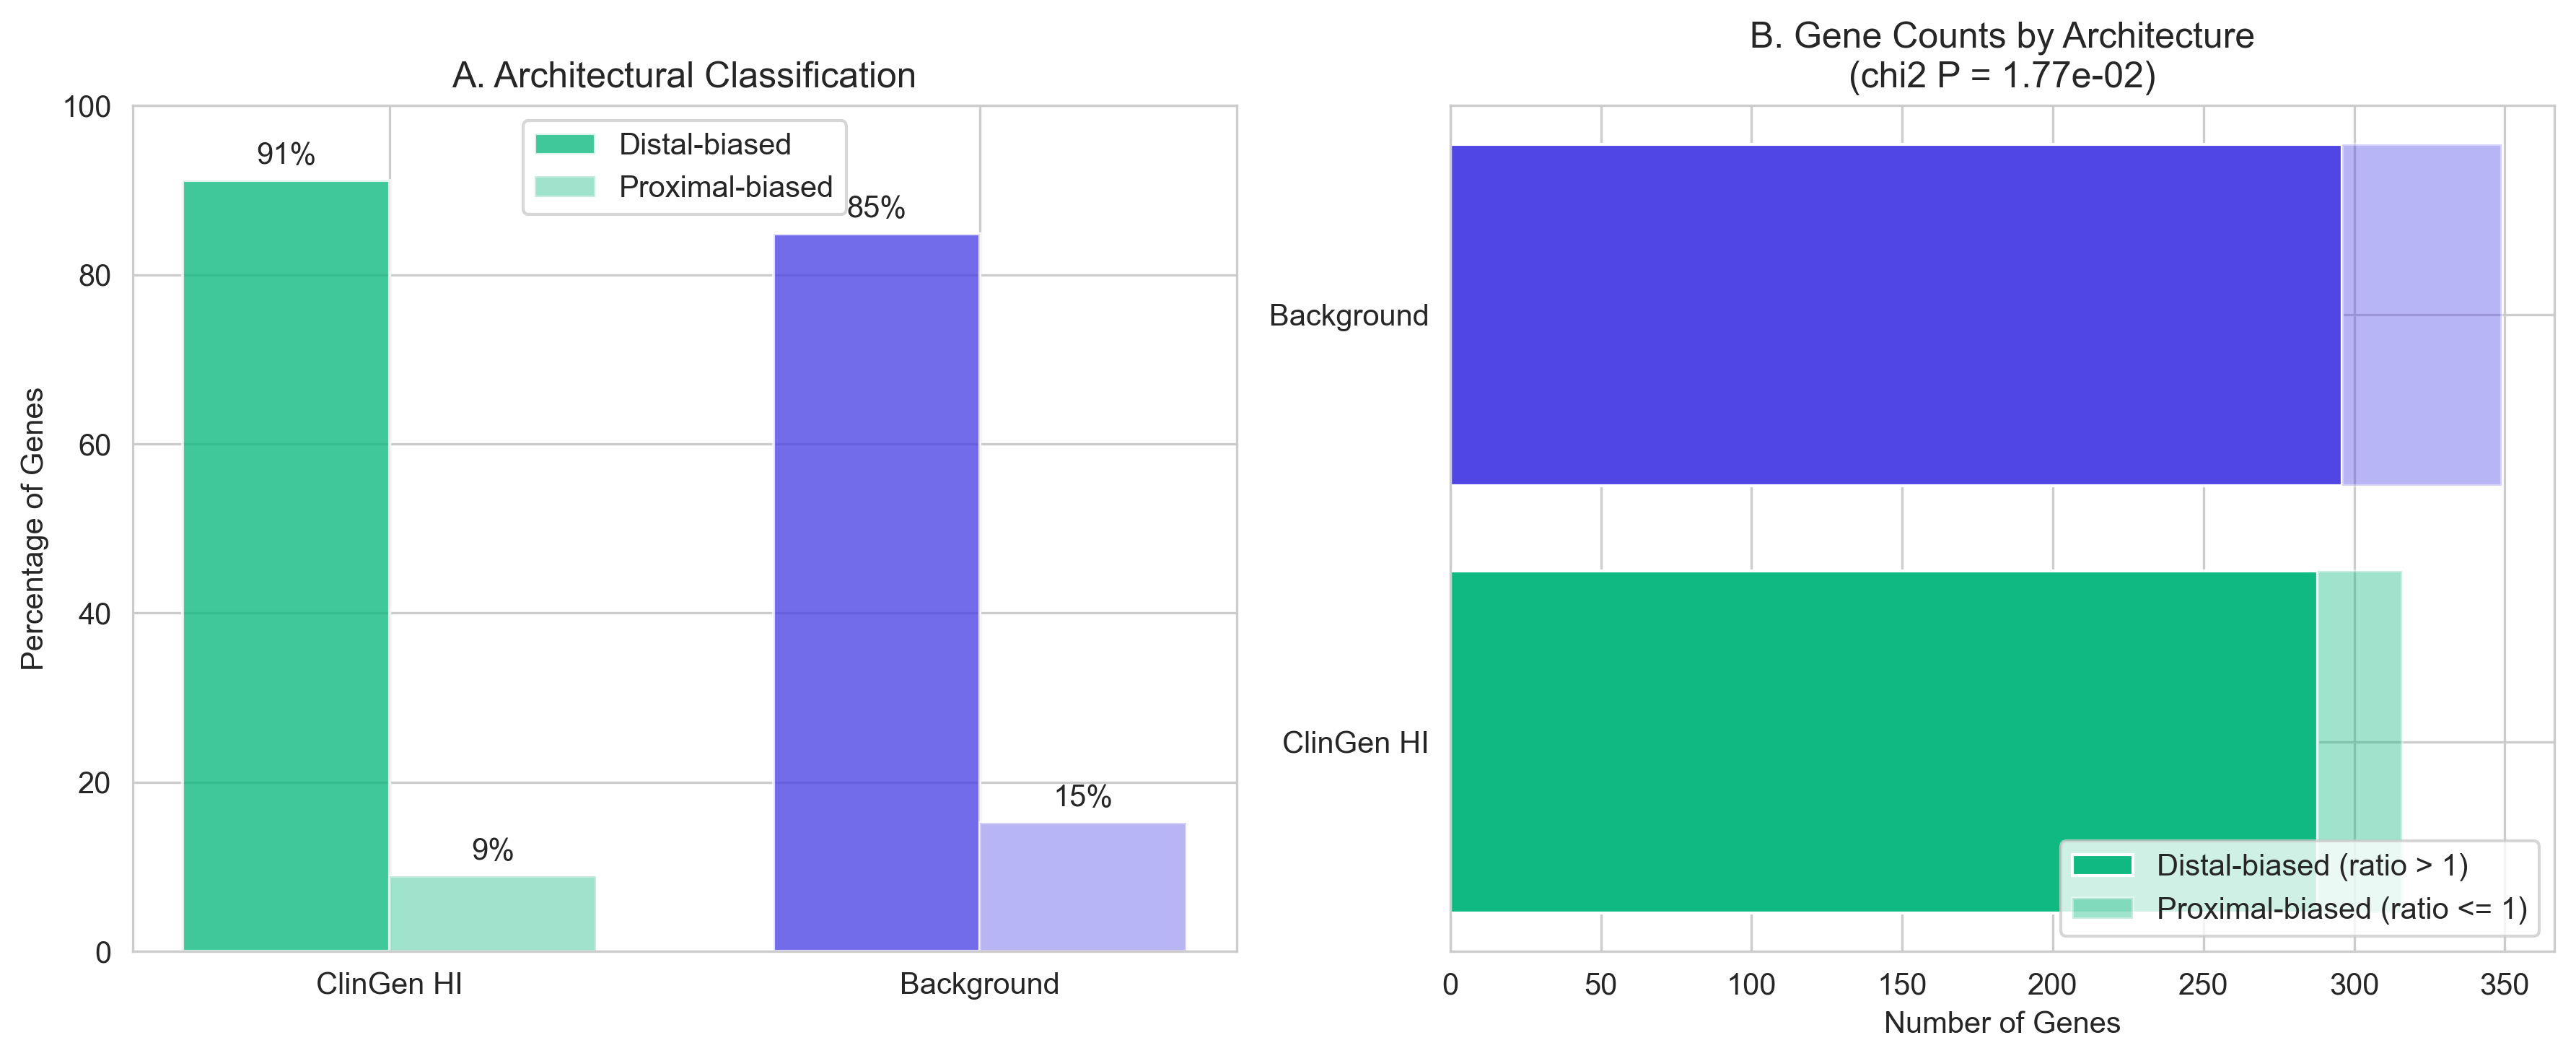

[save_plot] Saved: 03_Architectural_Redistribution_3.3_Architecture_Prevalence_20022026_1232.pdf
[save_plot] Saved: 03_Architectural_Redistribution_3.3_Architecture_Prevalence_20022026_1232.svg


<Figure size 1920x1440 with 0 Axes>

In [11]:
# Visualize prevalence
with autosave('3.3_Architecture_Prevalence', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Panel A: Grouped bar chart
    ax = axes[0]
    x = np.arange(2)
    width = 0.35
    
    distal_pcts = [hi_pct_distal, bg_pct_distal]
    proximal_pcts = [100 - hi_pct_distal, 100 - bg_pct_distal]
    
    bars1 = ax.bar(x - width/2, distal_pcts, width, label='Distal-biased', 
                   color=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']], alpha=0.8)
    bars2 = ax.bar(x + width/2, proximal_pcts, width, label='Proximal-biased',
                   color=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']], alpha=0.4)
    
    ax.set_ylabel('Percentage of Genes')
    ax.set_title('A. Architectural Classification')
    ax.set_xticks(x)
    ax.set_xticklabels(['ClinGen HI', 'Background'])
    ax.legend()
    ax.set_ylim(0, 100)
    
    # Add percentage labels
    for i, (d, p) in enumerate(zip(distal_pcts, proximal_pcts)):
        ax.text(i - width/2, d + 2, f'{d:.0f}%', ha='center', fontsize=10)
        ax.text(i + width/2, p + 2, f'{p:.0f}%', ha='center', fontsize=10)
    
    # Panel B: Stacked bar
    ax = axes[1]
    groups = ['ClinGen HI', 'Background']
    distal_counts = [hi_distal_biased, bg_distal_biased]
    proximal_counts = [hi_proximal_biased, bg_proximal_biased]
    
    ax.barh(groups, distal_counts, label='Distal-biased (ratio > 1)', 
            color=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']])
    ax.barh(groups, proximal_counts, left=distal_counts, label='Proximal-biased (ratio <= 1)',
            color=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']], alpha=0.4)
    
    ax.set_xlabel('Number of Genes')
    ax.set_title(f'B. Gene Counts by Architecture\n(chi2 P = {pval_chi:.2e})')
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

## 3.4 Spatial Variance Breakdown

Show the variance distribution across all spatial regions.

In [12]:
regions = ['distal_upstream', 'proximal_upstream', 'promoter_core', 'down_proximal', 'down_distal']
region_labels = ['Distal\nUpstream', 'Proximal\nUpstream', 'Promoter\nCore', 'Proximal\nDownstream', 'Distal\nDownstream']

hi_medians = []
bg_medians = []

print('VARIANCE BY SPATIAL REGION')
print(f'{"Region":<25} {"HI Median":>12} {"BG Median":>12} {"Fold":>8} {"P-value":>12}')
print('-' * 74)

for region in regions:
    col = f'vg_{region}'
    hi_vals = df_hi[col].drop_nulls().to_numpy()
    bg_vals = df_bg[col].drop_nulls().to_numpy()
    
    hi_med = np.median(hi_vals)
    bg_med = np.median(bg_vals)
    fold = hi_med / bg_med if bg_med > 0 else np.nan
    
    stat, pval_region = stats.mannwhitneyu(hi_vals, bg_vals, alternative='two-sided')
    
    hi_medians.append(hi_med)
    bg_medians.append(bg_med)
    
    print(f'{region:<25} {hi_med:>12.6f} {bg_med:>12.6f} {fold:>8.2f}x {pval_region:>12.2e}')

VARIANCE BY SPATIAL REGION
Region                       HI Median    BG Median     Fold      P-value
--------------------------------------------------------------------------
distal_upstream               0.000229     0.000155     1.48x     9.10e-02
proximal_upstream             0.000055     0.000039     1.43x     5.96e-02
promoter_core                 0.000041     0.000096     0.42x     1.15e-07
down_proximal                 0.000113     0.000195     0.58x     4.63e-03
down_distal                   0.000441     0.000628     0.70x     1.20e-02


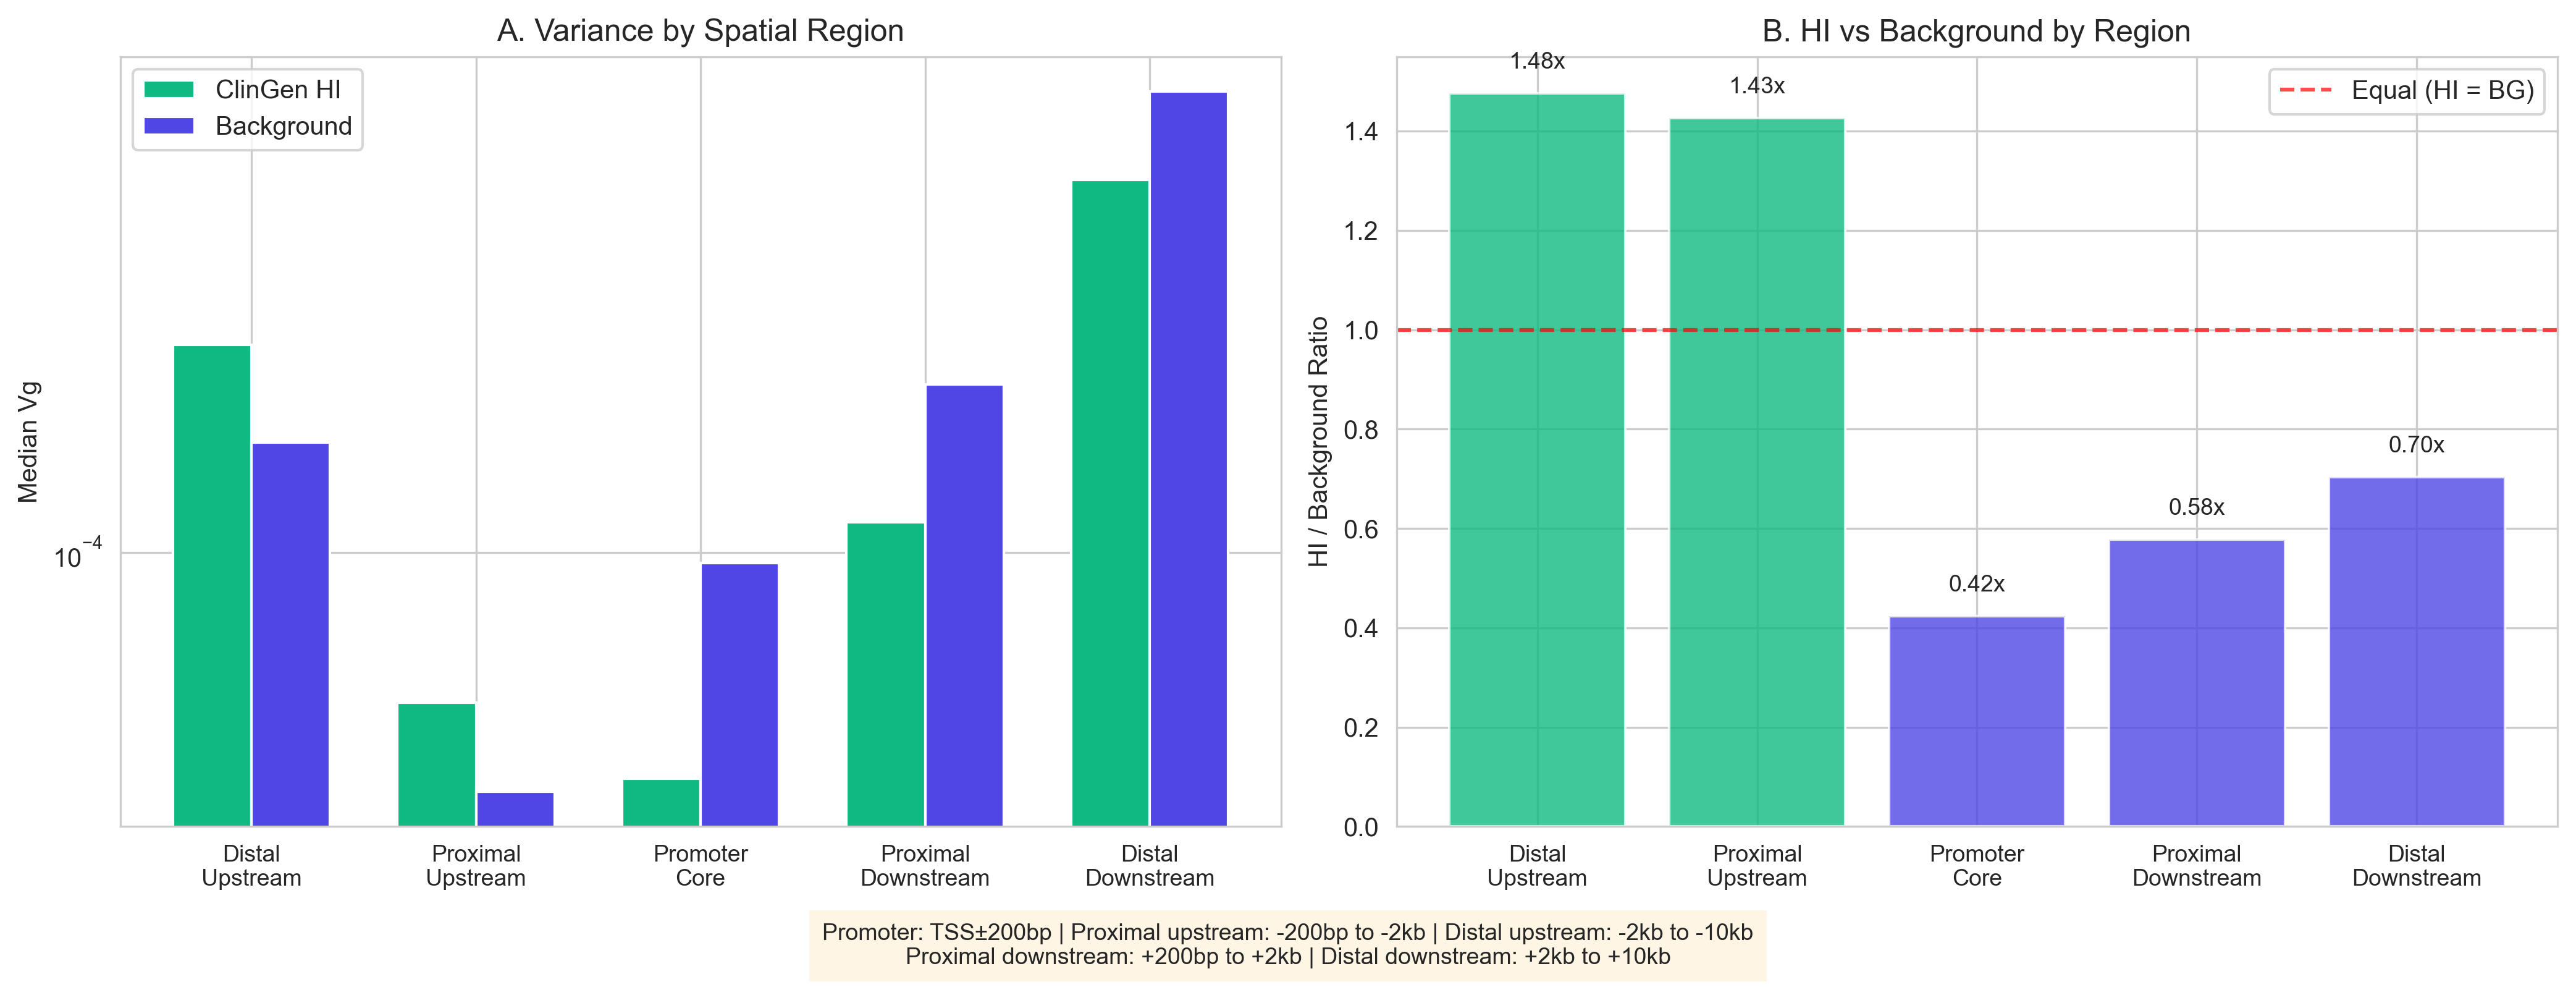

[save_plot] Saved: 03_Architectural_Redistribution_3.4_Spatial_Variance_Breakdown_20022026_1232.pdf
[save_plot] Saved: 03_Architectural_Redistribution_3.4_Spatial_Variance_Breakdown_20022026_1232.svg


<Figure size 1920x1440 with 0 Axes>

In [13]:
with autosave('3.4_Spatial_Variance_Breakdown', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    x = np.arange(len(regions))
    width = 0.35

    ax.bar(x - width/2, hi_medians, width, label='ClinGen HI', color=SOURCE_PALETTE['clingen'])
    ax.bar(x + width/2, bg_medians, width, label='Background', color=SOURCE_PALETTE['background'])

    ax.set_ylabel('Median Vg')
    ax.set_title('A. Variance by Spatial Region')
    ax.set_xticks(x)
    ax.set_xticklabels(region_labels, fontsize=9)
    ax.legend()
    ax.set_yscale('log')

    ax = axes[1]
    ratios = [h/b if b > 0 else 0 for h, b in zip(hi_medians, bg_medians)]
    colors = [SOURCE_PALETTE['clingen'] if r > 1 else SOURCE_PALETTE['background'] for r in ratios]

    ax.bar(x, ratios, color=colors, alpha=0.8)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Equal (HI = BG)')
    ax.set_ylabel('HI / Background Ratio')
    ax.set_title('B. HI vs Background by Region')
    ax.set_xticks(x)
    ax.set_xticklabels(region_labels, fontsize=9)
    ax.legend()

    for i, r in enumerate(ratios):
        ax.text(i, r + 0.05, f'{r:.2f}x', ha='center', fontsize=9)

    plt.figtext(0.5, -0.05,
                "Promoter: TSS±200bp | Proximal upstream: -200bp to -2kb | Distal upstream: -2kb to -10kb\n"
                "Proximal downstream: +200bp to +2kb | Distal downstream: +2kb to +10kb",
                ha="center", fontsize=9, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

    plt.tight_layout()
    plt.show()

## 3.5 ENCODE Validation: Enhancer Density

**Independent validation:** Do HI genes have more enhancers (ENCODE cCRE data)?

**Abstract claim:** "HI genes have significantly more enhancers (28 vs 24 per gene, P<10-6)"


Do HI genes have fewer proximal TF binding peaks (Sparse)? but they have significantly higher signal intensity per peak (Strong/High Affinity).

Data was downloaded from here: https://screen.wenglab.org/


Promoter-like (PLS) (2.6 MB): Core promoter regions.
Hypothesis: HI genes often have larger, more complex promoter architectures.
All Candidate Enhancers (pELS & dELS) (94.4 MB):  Enhancers (proximal and distal) that regulate gene expression levels.
Hypothesis: HI genes require precise "fine-tuning," so they should be surrounded by more enhancers than background genes.

In [14]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from scipy import stats
import numpy as np
import sys

from config import SOURCE_PALETTE
from utils.plot_utils import autosave, save_plot

PROMOTER_LIKE_PLS_BED = "/Users/markus/in-silico-vg-analysis/experiments_data/GRCh38-cCREs.PLS.bed"
ALL_CANDIDATE_ENHANCERS_BED = "/Users/markus/in-silico-vg-analysis/experiments_data/GRCh38-cCREs.ELS.bed"

BED_PATHS = {
    'clingen': '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/dataset3_ClinGen/ClinGen_gene_curation_list_GRCh38.ensg±10kb.bed',
    'background': '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/dataset4_background/background_gene_set±10kb.bed'
}

NAME_MAP = {
    'background': 'Background_Gnomad',
    'clingen': 'ClinGen_HI_Gnomad'
}

def cohens_d(x, y):
    """Calculate Cohen's d for independent samples."""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

def load_ccre(path, label):
    try:
        return pl.read_csv(
            path, separator='\t', has_header=False,
            new_columns=['chrom', 'start', 'end', 'id1', 'id2', 'type_raw'],
            truncate_ragged_lines=True
        ).select(['chrom', 'start', 'end'])
    except Exception as e:
        print(f"Error loading {label}: {e}")
        return pl.DataFrame()

def load_genes(paths):
    dfs = []
    for source, path in paths.items():
        try:
            d = pl.read_csv(
                path, separator='\t', has_header=False,
                new_columns=['chrom', 'start', 'end', 'raw_name']
            )
            dfs.append(d.with_columns([
                pl.col('raw_name').str.split('|').list.get(0).alias('gene_id'),
                pl.lit(source).alias('source')
            ]).select(['chrom', 'start', 'end', 'gene_id', 'source']))
        except Exception as e:
             print(f"Error loading gene path {path}: {e}")
    return pl.concat(dfs)

def run_intersection(genes, ccre, label):
    """Geometric intersection: Count cCREs inside gene windows."""
    ccre_lazy = ccre.lazy().rename({"start": "c_start", "end": "c_end"})

    intersections = (
        genes.lazy()
        .join(ccre_lazy, on="chrom", how="inner")
        .filter(
            (pl.col("c_start") < pl.col("end")) &
            (pl.col("c_end") > pl.col("start"))
        )
        .group_by("gene_id")
        .agg(pl.len().alias("count"))
    )

    return (
        genes.lazy().select("gene_id").unique()
        .join(intersections, on="gene_id", how="left")
        .fill_null(0)
        .collect()
        .with_columns(pl.lit(label).alias("type"))
    )

def plot_results(df):
    df_pd = df.to_pandas()
    df_pd['Source'] = df_pd['source'].map(NAME_MAP)

    palette = {
        'Background_Gnomad': SOURCE_PALETTE['background'],
        'ClinGen_HI_Gnomad': SOURCE_PALETTE['clingen']
    }

    plot_configs = [
        ('PLS', 'A. Promoter Complexity (PLS)'),
        ('ELS', 'B. Enhancer Density (ELS)')
    ]


    with autosave("Figure_S2_Regulatory_Complexity"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))

        for ax, (rtype, title) in zip(axes, plot_configs):
            subset = df_pd[df_pd['type'] == rtype]

            bg_data = subset[subset['Source'] == 'Background_Gnomad']['count'].values
            hi_data = subset[subset['Source'] == 'ClinGen_HI_Gnomad']['count'].values

            stat, pval = stats.mannwhitneyu(hi_data, bg_data, alternative='greater')
            d_val = cohens_d(hi_data, bg_data)

            print(f'\n{title}:')
            print(f'  ClinGen HI: median = {np.median(hi_data):.0f}, mean = {np.mean(hi_data):.1f}')
            print(f'  Background: median = {np.median(bg_data):.0f}, mean = {np.mean(bg_data):.1f}')
            print(f'  P-value (one-sided, HI > BG): {pval:.2e}')
            print(f'  Cohen\'s d: {d_val:.3f}')

            if rtype == 'ELS':
                if pval < 0.05:
                    print(f"HI genes have significantly denser enhancer networks (P={pval:.1e})")
                else:
                    print(f"No significant enrichment found (P={pval:.1e})")

            sns.violinplot(
                data=subset, x='Source', y='count',
                hue='Source', palette=palette, ax=ax,
                legend=False, inner='quartile', linewidth=1.2
            )

            labels = [l.get_text() for l in ax.get_xticklabels()]
            for i, label in enumerate(labels):
                grp_data = subset[subset['Source'] == label]['count']
                median = grp_data.median()
                mean = grp_data.mean()

                txt = ax.text(i, median, f'Med: {median:.1f}\nMean: {mean:.1f}',
                        ha='center', va='center', color='white', fontweight='bold', fontsize=10)
                txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])

            y_max = subset['count'].max()
            h = y_max * 0.05
            ax.plot([0, 0, 1, 1], [y_max, y_max+h, y_max+h, y_max], lw=1.5, c='k')
            ax.text(0.5, y_max + h, f"P = {pval:.2e}\nd = {d_val:.2f}", ha='center', va='bottom', fontsize=11)

            ax.set_title(title, fontweight='bold', pad=20)
            ax.set_ylabel("Count (Regulatory Elements per Gene)")
            ax.set_xlabel("")

        plt.tight_layout()

if __name__ == "__main__":
    df_genes = load_genes(BED_PATHS)
    df_pls = load_ccre(PROMOTER_LIKE_PLS_BED, "PLS")
    df_els = load_ccre(ALL_CANDIDATE_ENHANCERS_BED, "ELS")

    res_pls = run_intersection(df_genes, df_pls, "PLS")
    res_els = run_intersection(df_genes, df_els, "ELS")

    final_df = pl.concat([res_pls, res_els]).join(
        df_genes.select(['gene_id', 'source']).unique(), on='gene_id'
    )

    plot_results(final_df)

Error loading gene path /Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/dataset3_ClinGen/ClinGen_gene_curation_list_GRCh38.ensg±10kb.bed: No such file or directory (os error 2): ...ws25/data/intermediate/dataset3_ClinGen/ClinGen_gene_curation_list_GRCh38.ensg±10kb.bed (set POLARS_VERBOSE=1 to see full path)
Error loading gene path /Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/dataset4_background/background_gene_set±10kb.bed: No such file or directory (os error 2): ...-biotech-CB206V-ws25/data/intermediate/dataset4_background/background_gene_set±10kb.bed (set POLARS_VERBOSE=1 to see full path)


ValueError: cannot concat empty list

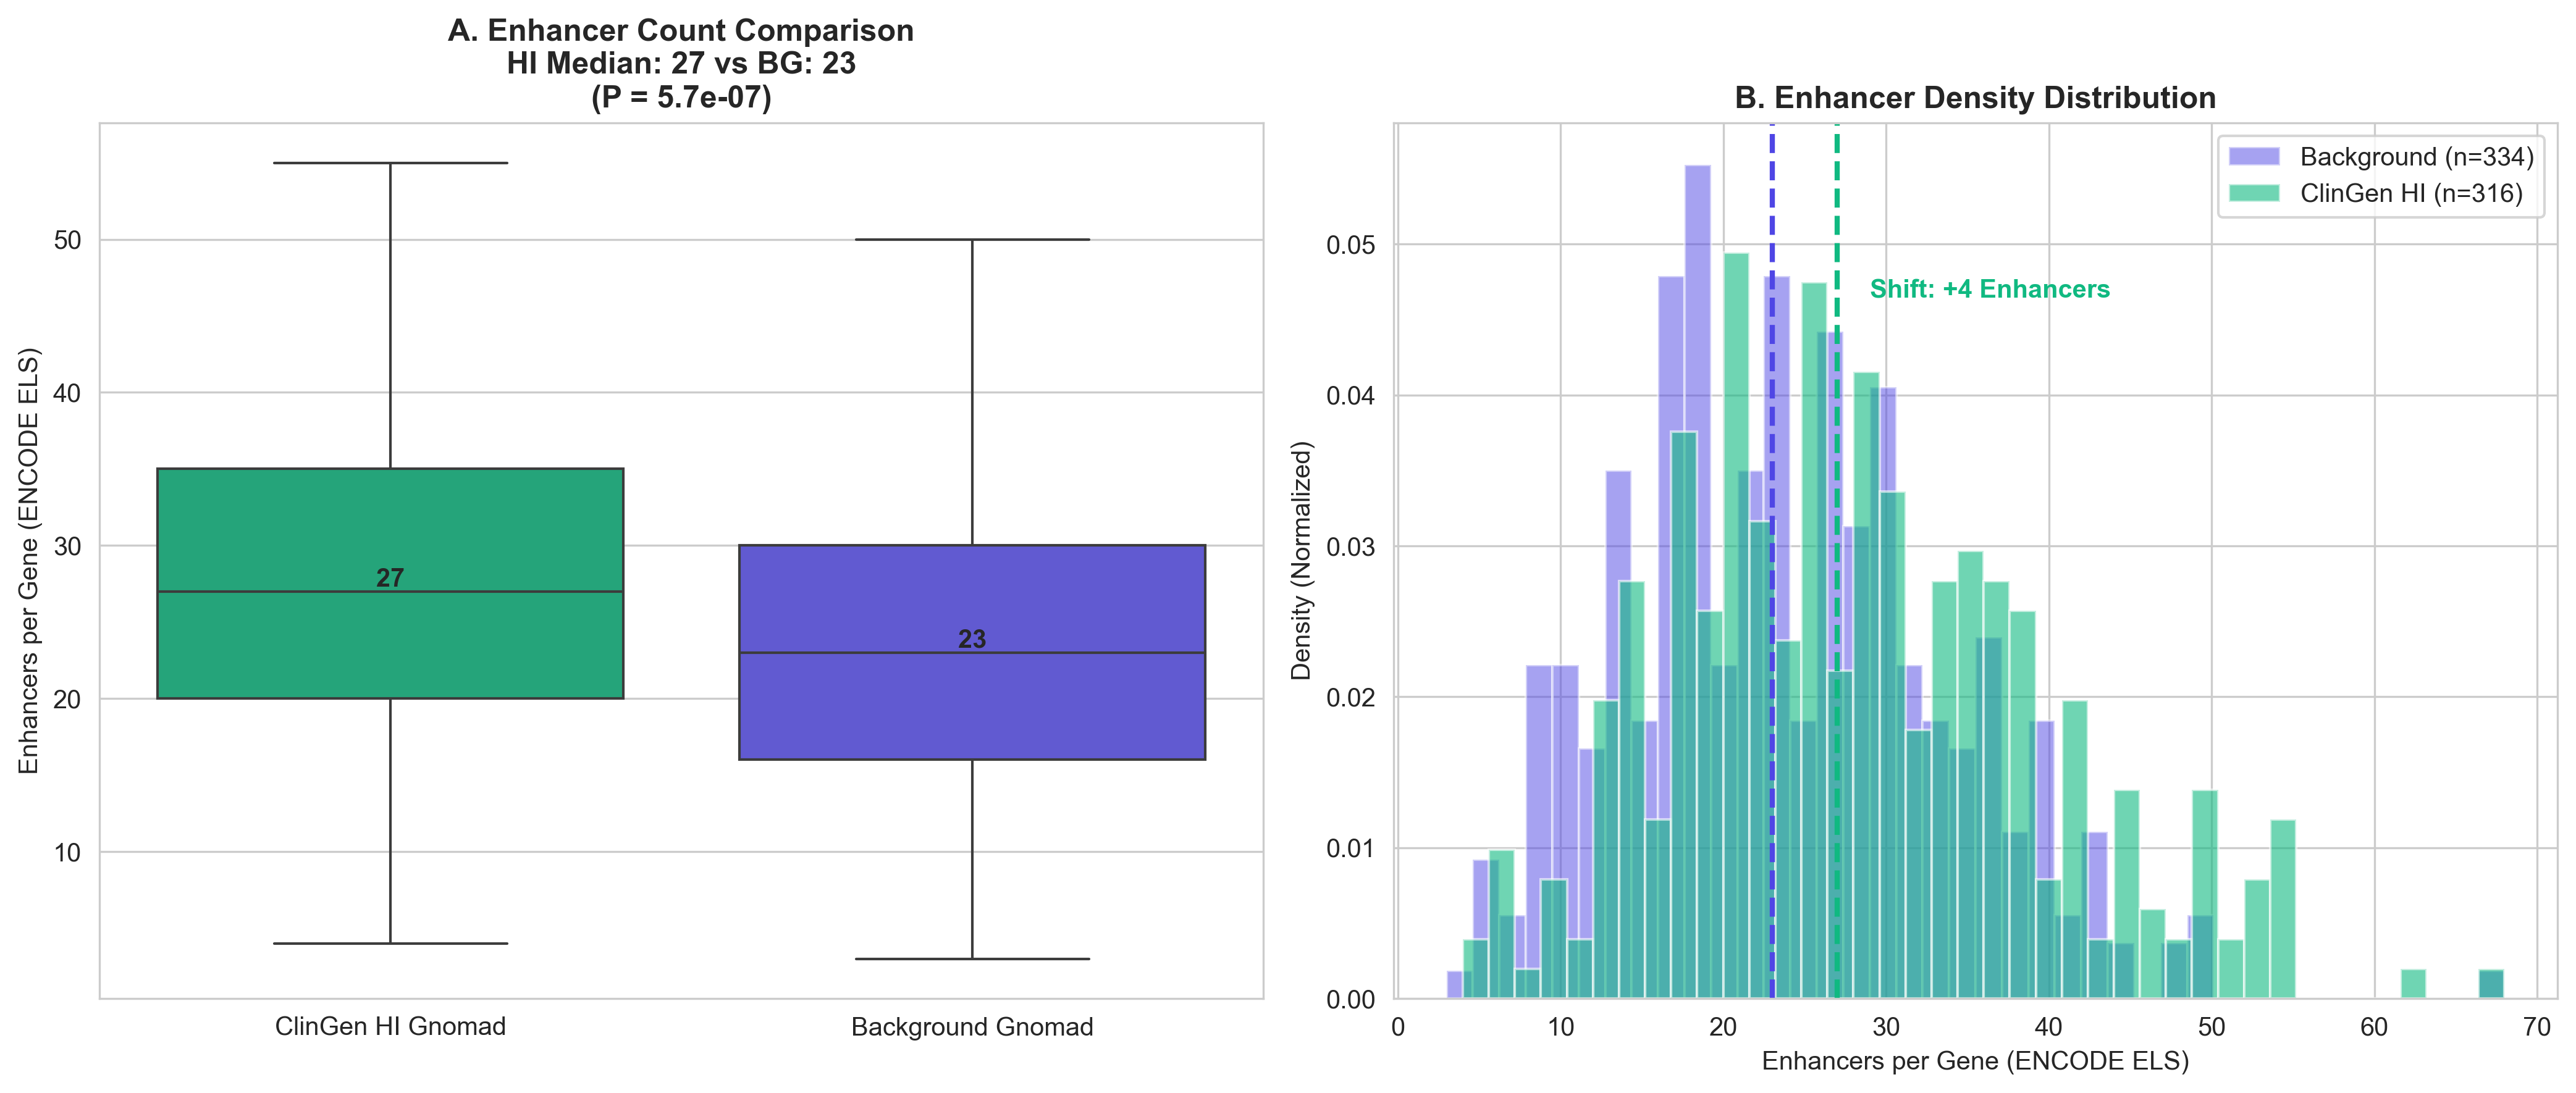

[save_plot] Saved: 03_Architectural_Redistribution_3.5_ENCODE_Enhancer_Validation_06022026_1459.pdf
[save_plot] Saved: 03_Architectural_Redistribution_3.5_ENCODE_Enhancer_Validation_06022026_1459.svg


<Figure size 1920x1440 with 0 Axes>

In [ ]:
subset_els = final_df.filter(pl.col("type") == "ELS")
hi_enh = subset_els.filter(pl.col("source") == "clingen")['count'].to_numpy()
bg_enh = subset_els.filter(pl.col("source") == "background")['count'].to_numpy()

stat, pval_enh = stats.mannwhitneyu(hi_enh, bg_enh, alternative='greater')

with autosave('3.5_ENCODE_Enhancer_Validation', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    data = [hi_enh, bg_enh]
    sns.boxplot(data=data, ax=ax, palette=[SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']], showfliers=False)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['ClinGen HI Gnomad', 'Background Gnomad'])
    ax.set_ylabel('Enhancers per Gene (ENCODE ELS)')
    ax.set_title(f'A. Enhancer Count Comparison\nHI Median: {np.median(hi_enh):.0f} vs BG: {np.median(bg_enh):.0f}\n(P = {pval_enh:.1e})', fontweight='bold')

    for i, d in enumerate(data):
        ax.text(i, np.median(d), f'{np.median(d):.0f}', ha='center', va='bottom', fontweight='bold')

    ax = axes[1]
    ax.hist(bg_enh, bins=40, density=True, alpha=0.5, color=SOURCE_PALETTE['background'], label=f'Background (n={len(bg_enh)})')
    ax.hist(hi_enh, bins=40, density=True, alpha=0.6, color=SOURCE_PALETTE['clingen'], label=f'ClinGen HI (n={len(hi_enh)})', edgecolor='white')

    ax.axvline(np.median(bg_enh), color=SOURCE_PALETTE['background'], linestyle='--', lw=2)
    ax.axvline(np.median(hi_enh), color=SOURCE_PALETTE['clingen'], linestyle='--', lw=2)

    ax.text(np.median(hi_enh) + 2, ax.get_ylim()[1] * 0.8,
            f'Shift: +{np.median(hi_enh) - np.median(bg_enh):.0f} Enhancers',
            color=SOURCE_PALETTE['clingen'], fontweight='bold')

    ax.set_xlabel('Enhancers per Gene (ENCODE ELS)')
    ax.set_ylabel('Density (Normalized)')
    ax.set_title('B. Enhancer Density Distribution', fontweight='bold')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


## 3.6 Real vs Synthetic: Selection Signal in Architecture

Now we ask if the distal-biased architecture an evolved feature or just genomic context?

So we compare distal:core ratios between Real and Synthetic variants.
If Real > Synth: selection has amplified distal regulatory control
If Real ~ Synth: architecture is just genomic context

In [ ]:
df_ratios = (
    final_df.pivot(
        index=['gene_id', 'source'],
        on='type',
        values='count',
        aggregate_function='sum'
    )
    .fill_null(0)
    .with_columns(
        # Calculate Ratio: ELS / PLS
        (pl.col('ELS') / pl.col('PLS').clip(lower_bound=1)).alias('ratio')
    )
)

hi_ratio = df_ratios.filter(pl.col('source') == 'clingen')['ratio'].to_numpy()
bg_ratio = df_ratios.filter(pl.col('source') == 'background')['ratio'].to_numpy()

print(f'\nDistal:Core Ratio Comparison (HI vs Background):')

stat, pval = stats.mannwhitneyu(hi_ratio, bg_ratio, alternative='two-sided')

print(f'  ClinGen HI: Median Ratio = {np.median(hi_ratio):.2f}, Mean = {np.mean(hi_ratio):.2f}')
print(f'  Background: Median Ratio = {np.median(bg_ratio):.2f}, Mean = {np.mean(bg_ratio):.2f}')
print(f'  P-value: {pval:.2e}')

NameError: name 'final_df' is not defined

ok thats interesting, so while HI genes have more regulation overall (both more promoters and more enhancers), the balance between them (the topology) scales proportionally with background genes. Complexity increases globally, not just distally. Since HI genes have MORE Promoters AND MORE Enhancers (from previous plots), this means complexity scales globally. They are 'heavier' in all aspects,  rather than just being shifted toward distal regulation.")

[save_plot] Saved: 03_Architectural_Redistribution_3.6_Architecture_Selection_Signal_19022026_1152.pdf
[save_plot] Saved: 03_Architectural_Redistribution_3.6_Architecture_Selection_Signal_19022026_1152.svg


NameError: name 'bg_ratio' is not defined

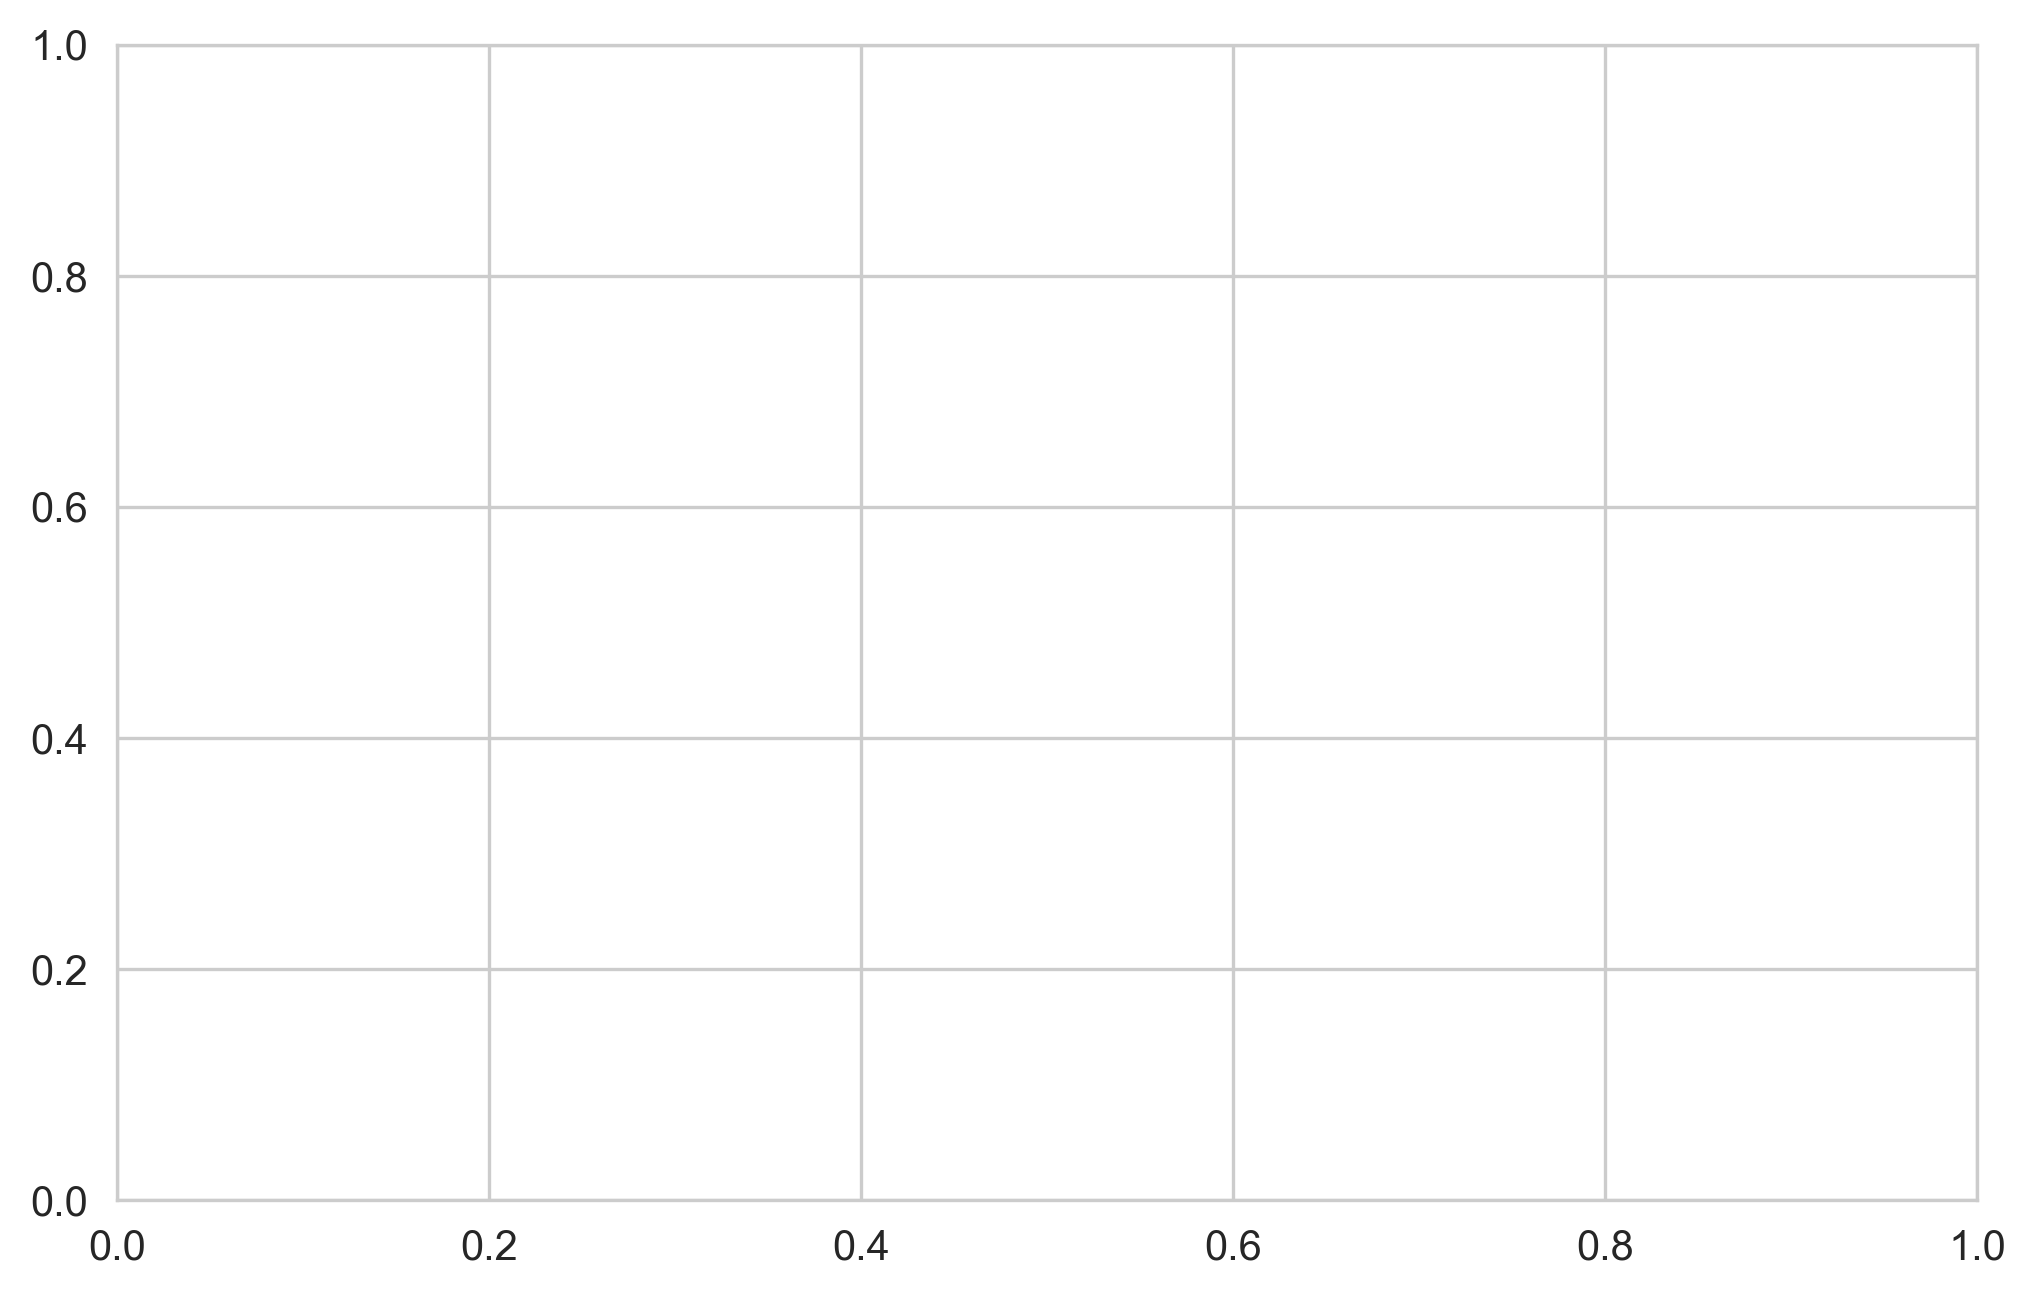

In [ ]:
with autosave('3.6_Architecture_Selection_Signal', notebook=NOTEBOOK_NAME):
    fig, ax = plt.subplots(figsize=(8, 5))

    data = [bg_ratio, hi_ratio]
    sns.boxplot(data=data, ax=ax, palette=[SOURCE_PALETTE['background'], SOURCE_PALETTE['clingen']], showfliers=False)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Background', 'ClinGen HI'])
    ax.set_ylabel('Distal:Core Ratio (Enhancers / Promoters)')
    ax.set_title(f'Regulatory Topology Comparison\n(P = {pval:.2e})')

    ax.set_yscale('log')
    from matplotlib.ticker import ScalarFormatter
    ax.yaxis.set_major_formatter(ScalarFormatter())

    for i, d in enumerate(data):
        ax.text(i, np.median(d), f'{np.median(d):.2f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

here we show that hploinsufficient genes don't just "switch" to using distal regulation (enhancers) at the expense of local regulation (promoters) they scale up the entire regulatory machinery. They are "heavier" genes in every dimension—more inputs, more switches, more complexity—maintaining a strict 10:1 topological balance even as they grow larger.


## 3.7 Summary table

In [ ]:

summary_data = []

# Distal:Core ratio
stat, pval_ratio = stats.mannwhitneyu(hi_ratio, bg_ratio, alternative='two-sided')
summary_data.append({
    'Metric': 'Distal:Core Ratio',
    'HI Median': f'{np.median(hi_ratio):.2f}',
    'BG Median': f'{np.median(bg_ratio):.2f}',
    'Fold/Diff': f'{np.median(hi_ratio)/np.median(bg_ratio):.1f}x',
    'P-value': f'{pval_ratio:.2e}',
    "Cohen's d": f'{cohens_d(hi_ratio, bg_ratio):.2f}'
})

# % Distal-biased
summary_data.append({
    'Metric': '% Distal-biased',
    'HI Median': f'{hi_pct_distal:.1f}%',
    'BG Median': f'{bg_pct_distal:.1f}%',
    'Fold/Diff': f'+{hi_pct_distal - bg_pct_distal:.1f}%',
    'P-value': f'{pval_chi:.2e}',
    "Cohen's d": '-'
})

# Enhancer count
summary_data.append({
    'Metric': 'Enhancers per Gene',
    'HI Median': f'{np.median(hi_enh):.0f}',
    'BG Median': f'{np.median(bg_enh):.0f}',
    'Fold/Diff': f'{np.median(hi_enh)/np.median(bg_enh):.2f}x',
    'P-value': f'{pval_enh:.2e}',
    "Cohen's d": f'{cohens_d(hi_enh, bg_enh):.2f}'
})

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

NameError: name 'hi_ratio' is not defined

## Figure 2: Architectural Redistribution

- A: Distal:Core Ratio comparison
- B: ENCODE Enhancer validation

In [ ]:
fold_enrichment = np.median(hi_ratio) / np.median(bg_ratio)
hi_pct_distal = 100 * np.mean(hi_ratio > 1.0)
bg_pct_distal = 100 * np.mean(bg_ratio > 1.0)

stat, pval = stats.mannwhitneyu(hi_ratio, bg_ratio, alternative='two-sided')
stat_enh, pval_enh = stats.mannwhitneyu(hi_enh, bg_enh, alternative='greater')

with autosave('Figure_2_Architectural_Redistribution', notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    palette = [SOURCE_PALETTE['clingen'], SOURCE_PALETTE['background']]

    ax = axes[0]
    data_a = [hi_ratio, bg_ratio]
    sns.boxplot(data=data_a, ax=ax, palette=palette, width=0.6, showfliers=False)

    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.set_yscale('log')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HI', 'BG'])
    ax.set_ylabel('Distal:Core Variance Ratio')
    ax.set_title(f'A. Regulatory Architecture\n{fold_enrichment:.1f}x higher distal bias in HI (P = {pval:.1e})')

    ax.text(0.05, 0.95, f'Distal-biased (>1.0):\nHI: {hi_pct_distal:.0f}%\nBG: {bg_pct_distal:.0f}%',
            transform=ax.transAxes, va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    for i, d in enumerate(data_a):
        ax.text(i, np.median(d), f'{np.median(d):.2f}', ha='center', va='bottom', fontweight='bold')

    ax = axes[1]
    data_b = [hi_enh, bg_enh]
    sns.boxplot(data=data_b, ax=ax, palette=palette, width=0.6, showfliers=False)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HI', 'BG'])
    ax.set_ylabel('Enhancers per Gene (ENCODE ELS)')
    ax.set_title(f'B. ENCODE Validation\nHI: {np.median(hi_enh):.0f} vs BG: {np.median(bg_enh):.0f} enhancers (P = {pval_enh:.1e})')

    for i, d in enumerate(data_b):
        ax.text(i, np.median(d), f'{np.median(d):.0f}', ha='center', va='bottom', fontweight='bold')

    plt.suptitle('HI Genes Redistribute Regulatory Control to Distal Regions', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

NameError: name 'hi_ratio' is not defined


## 3.8 Conclusions

In [ ]:
def cohens_d(x, y):
    """Calculate Cohen's d for independent samples."""
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

df_ratios = (
    final_df.pivot(index=['gene_id', 'source'], on='type', values='count', aggregate_function='sum')
    .fill_null(0)
    .with_columns((pl.col('ELS') / pl.col('PLS').clip(lower_bound=1)).alias('ratio'))
)
hi_ratio = df_ratios.filter(pl.col('source') == 'clingen')['ratio'].to_numpy()
bg_ratio = df_ratios.filter(pl.col('source') == 'background')['ratio'].to_numpy()

# B. Get Enhancer Counts
hi_enh = final_df.filter((pl.col('type') == 'ELS') & (pl.col('source') == 'clingen'))['count'].to_numpy()
bg_enh = final_df.filter((pl.col('type') == 'ELS') & (pl.col('source') == 'background'))['count'].to_numpy()

fold_enrichment = np.median(hi_ratio) / np.median(bg_ratio)
hi_pct_distal = 100 * np.mean(hi_ratio > 1.0)
bg_pct_distal = 100 * np.mean(bg_ratio > 1.0)

# Effect Sizes
d_ratio = cohens_d(hi_ratio, bg_ratio)
d_enh = cohens_d(hi_enh, bg_enh)

stat, pval_enh = stats.mannwhitneyu(hi_enh, bg_enh, alternative='greater')

NameError: name 'final_df' is not defined

In [ ]:
threshold = 10.0 #kinda random here but to distinguish gorups

hi_pct_distal = 100 * np.mean(hi_ratio > threshold)
bg_pct_distal = 100 * np.mean(bg_ratio > threshold)

conclusions = f"""


Findings:
  - HI genes show {fold_enrichment:.2f}x relative distal:core regulatory ratio
  - Median ratio: HI = {np.median(hi_ratio):.2f} vs BG = {np.median(bg_ratio):.2f}
  - Interpretation: HI genes maintain high complexity (approx 10:1) similar to background.

Prevelandce (Hyper-Distal > {int(threshold)}:1):
  - {hi_pct_distal:.1f}% of HI genes are hyper-distal (ratio > {int(threshold)})
  - vs {bg_pct_distal:.1f}% of background genes
  - Result: HI genes are NOT more distally skewed than background; they scale globally.

Encode tests:
  - HI genes have {np.median(hi_enh):.0f} vs {np.median(bg_enh):.0f} enhancers per gene
  - P = {pval_enh:.1e} - Confirms HI genes have significantly MORE total enhancers.

Effect sizes:
  - Distal:Core ratio: d = {d_ratio:.2f} (Topology is conserved)
  - Enhancer count:    d = {d_enh:.2f} (Complexity is increased)

"""

print(conclusions)

NameError: name 'hi_ratio' is not defined

# GENCODE: Upstream Diagnostic with Coding Region Filtering

In [ ]:
from pathlib import Path
import polars as pl

gencode_path = Path("/Users/markus/university/ML-in-biotech-CB206V-ws25/data/initial/gencode.v49.annotation.gtf")

def parse_gencode_cds(gtf_path):
    """Extract CDS regions with GENE_ID (not gene_name) and strip versions."""
    cds_regions = []

    with open(gtf_path) as f:
        for line in f:
            if line.startswith('#'):
                continue

            fields = line.strip().split('\t')
            if len(fields) < 9:
                continue

            if fields[2] != 'CDS':  # Only coding sequence
                continue

            chrom = fields[0]
            start = int(fields[3])
            end = int(fields[4])

            # Extract GENE_ID (not gene_name) and STRIP VERSION
            attrs = fields[8]
            gene_id = None
            for attr in attrs.split(';'):
                attr = attr.strip()
                if attr.startswith('gene_id'):
                    gene_id_raw = attr.split('"')[1]
                    gene_id = gene_id_raw.split('.')[0]  # STRIP VERSION
                    break

            if gene_id:
                cds_regions.append({
                    'chrom': chrom,
                    'start': start,
                    'end': end,
                    'gene_id': gene_id  # Use gene_id, not gene_name
                })

    return pl.DataFrame(cds_regions)

cds_df = parse_gencode_cds(gencode_path)
print(f"Loaded {cds_df.height:,} CDS regions from GENCODE")
print(f"Covering {cds_df['gene_id'].n_unique():,} unique genes")
print(f"\nSample gene IDs: {cds_df['gene_id'].unique().head(5).to_list()}")

Loaded 2,283,012 CDS regions from GENCODE
Covering 20,509 unique genes

Sample gene IDs: ['ENSG00000062096', 'ENSG00000110721', 'ENSG00000096088', 'ENSG00000099326', 'ENSG00000163393']



Statistical Summary (Real Data):


,Metric,HI Median,BG Median,P-value,Cohens d
0,Core Vg,0.0000,0.0001,9.98e-08,-0.125
1,Proximal/Core Ratio,1.4701,0.3821,3.82e-11,0.250
2,Distal/Core Ratio,5.7604,1.4371,2.03e-09,0.108
3,Core % of Total,0.0233,0.0445,1.31e-04,-0.243


/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_92912/2596859444.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


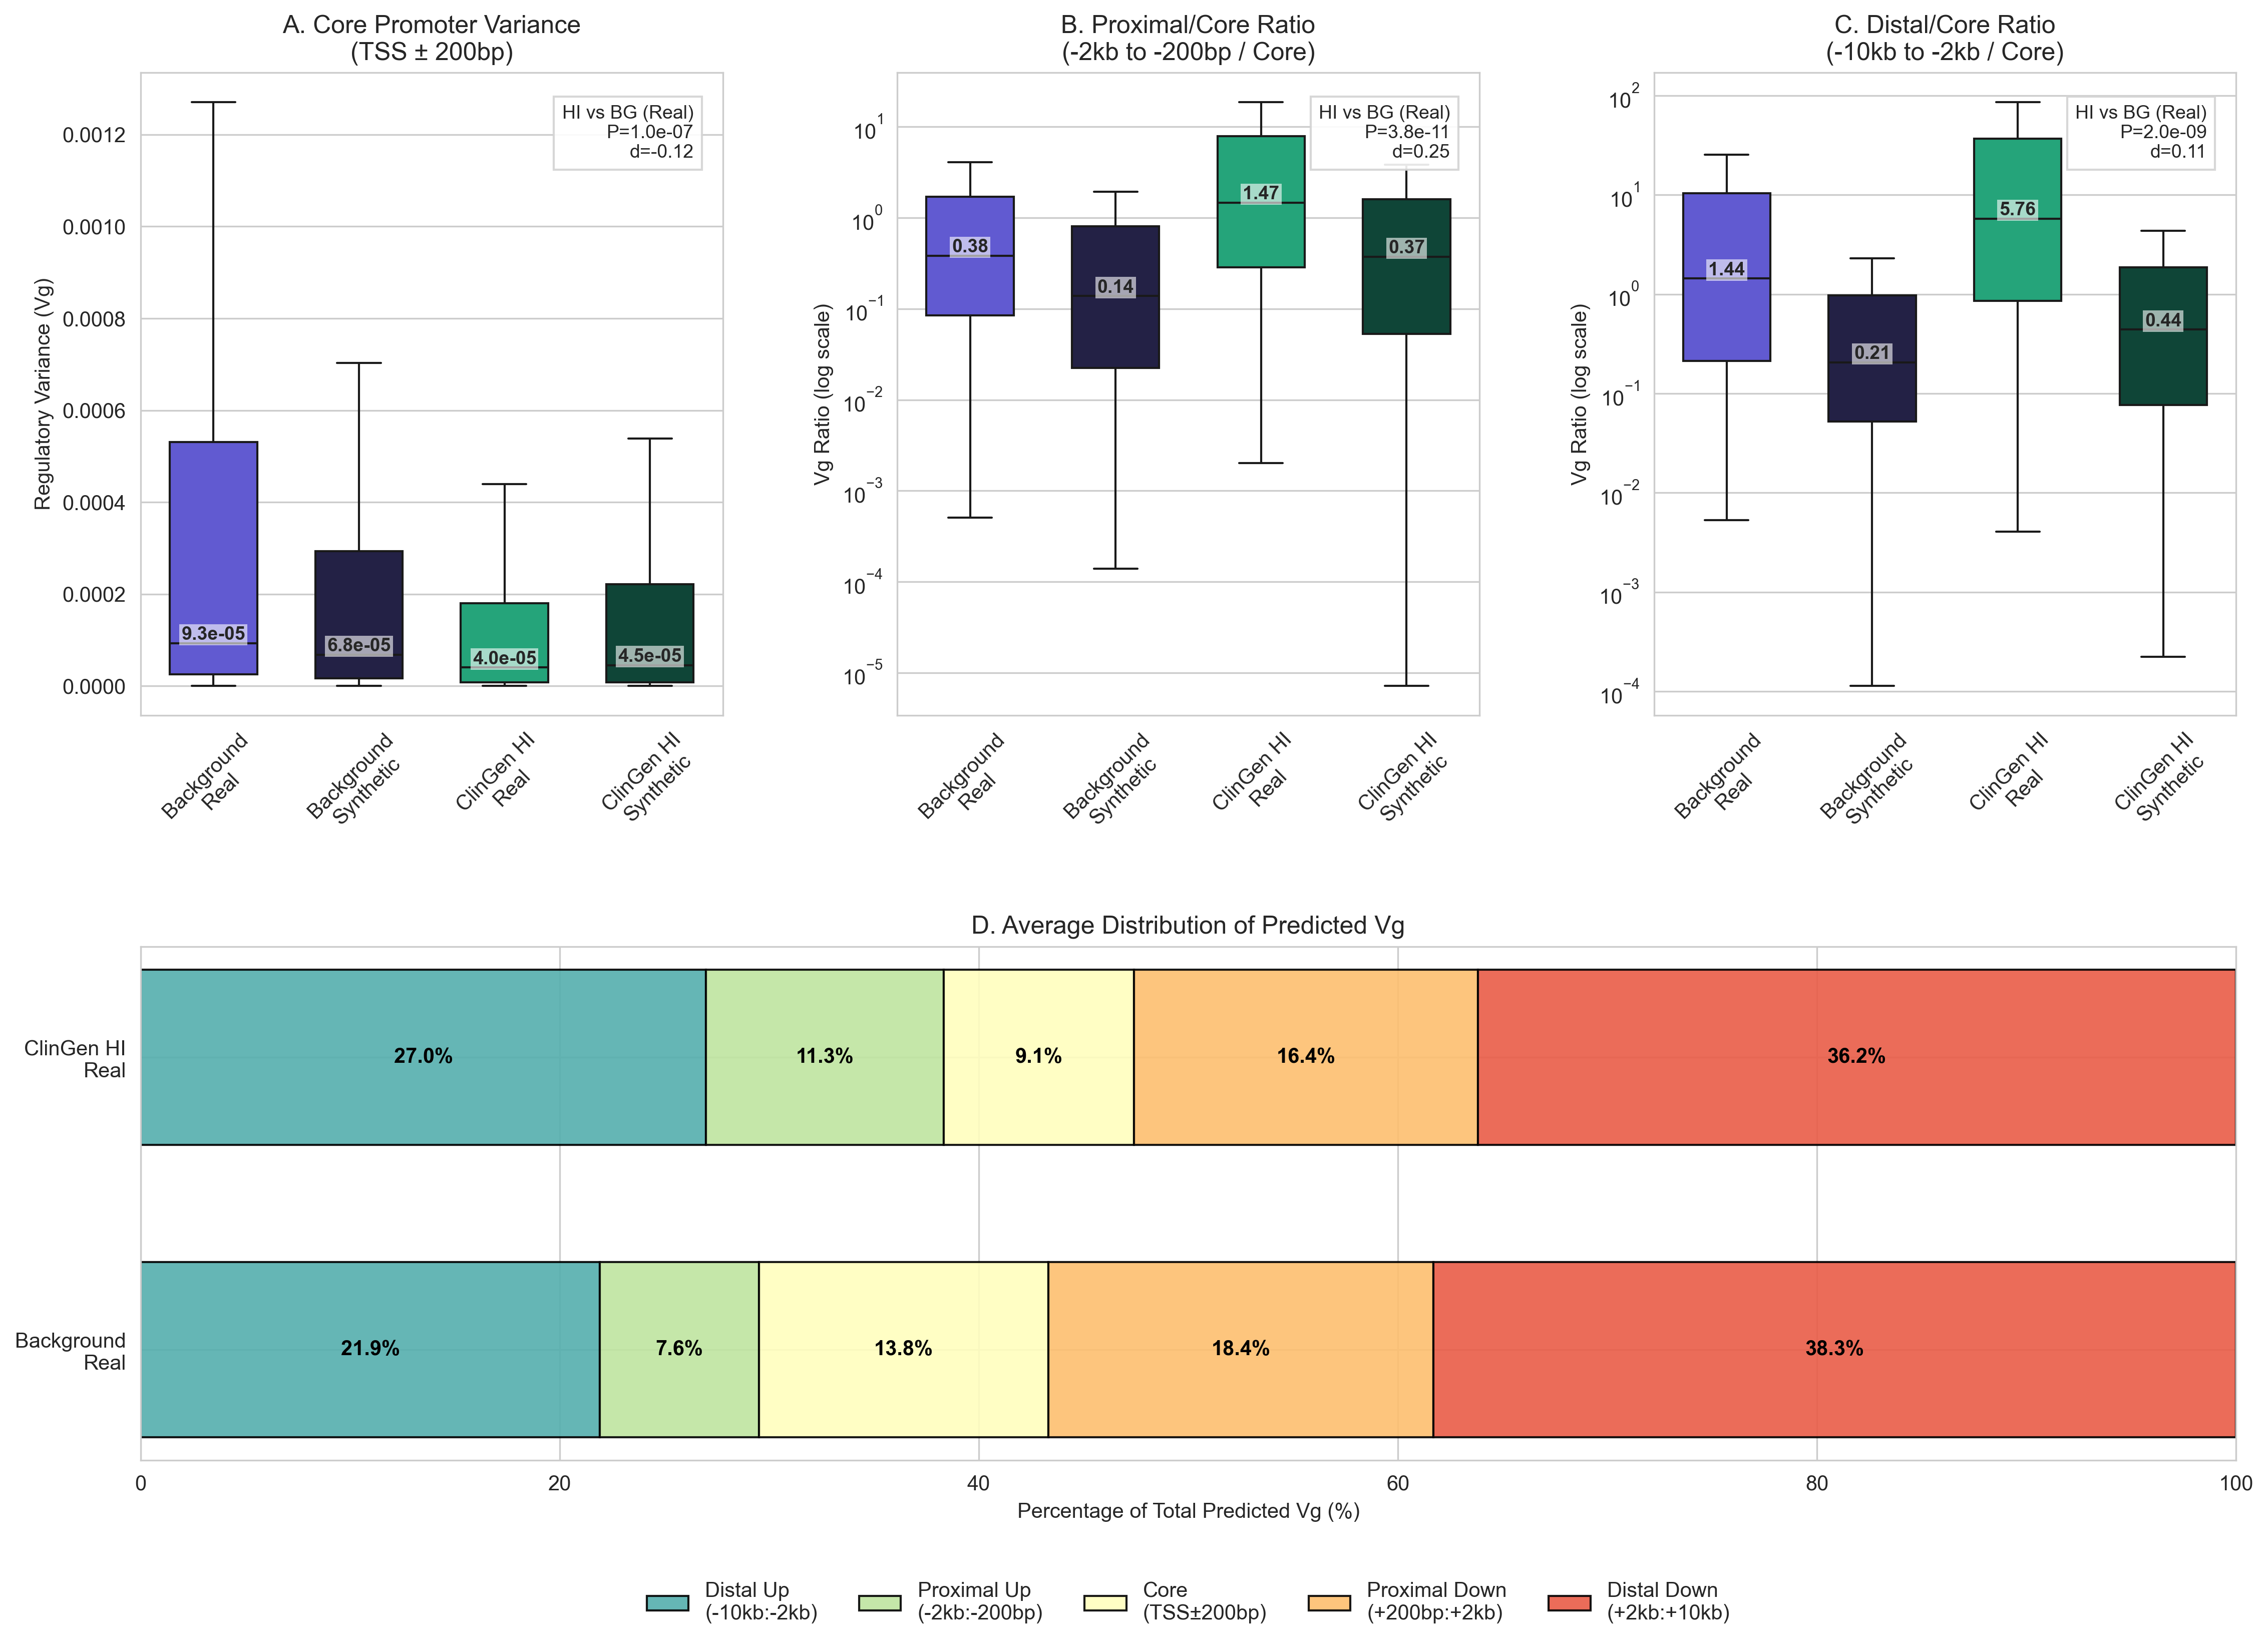

[save_plot] Saved: 03_Architectural_Redistribution_Figure_Spatial_Variance_Comprehensive_19022026_1152.pdf
[save_plot] Saved: 03_Architectural_Redistribution_Figure_Spatial_Variance_Comprehensive_19022026_1152.svg


<Figure size 1920x1440 with 0 Axes>

In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def cohens_d(x, y):
    """Calculates Cohen's d for independent samples with pooled standard deviation."""
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    # Pooled standard deviation
    pool_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pool_std

def get_spatial_metrics(df_real, df_synth):
    results = {}
    stats_rows = []

    # Define groups
    groups = {
        'HI_real': (df_real.filter(pl.col('source') == 'clingen'), False),
        'BG_real': (df_real.filter(pl.col('source') == 'background'), False),
        'HI_synth': (df_synth.filter(pl.col('source') == 'clingen_null'), True),
        'BG_synth': (df_synth.filter(pl.col('source') == 'background_null'), True)
    }

    for key, (df, is_synth) in groups.items():
        s = '_perm' if is_synth else ''
        # Map nice names to column names
        cols = {
            'vg_distal_up': f'vg_distal_upstream{s}',
            'vg_proximal_up': f'vg_proximal_upstream{s}',
            'vg_core': f'vg_promoter_core{s}',
            'vg_proximal_down': f'vg_down_proximal{s}',
            'vg_distal_down': f'vg_down_distal{s}'
        }

        # Extract numpy arrays
        data = {k: df[v].to_numpy() for k, v in cols.items()}
        
        # Calculate totals
        vg_total = sum(data.values())
        
        # Safety: Avoid division by zero for genes with 0 predicted variance
        # We set 0-variance genes to 1.0 denominator to result in 0/1 = 0 proportion
        vg_total_safe = np.where(vg_total == 0, 1.0, vg_total)
        vg_core_safe = np.where(data['vg_core'] == 0, 1e-10, data['vg_core'])

        # Store raw data and calculated ratios
        data.update({
            # Ratios relative to Core (for Boxplots A, B, C)
            'ratio_proximal': data['vg_proximal_up'] / vg_core_safe,
            'ratio_distal': data['vg_distal_up'] / vg_core_safe,
            
            # Proportions relative to Total (for Panel D)
            'prop_distal_up': data['vg_distal_up'] / vg_total_safe,
            'prop_proximal_up': data['vg_proximal_up'] / vg_total_safe,
            'prop_core': data['vg_core'] / vg_total_safe,
            'prop_proximal_down': data['vg_proximal_down'] / vg_total_safe,
            'prop_distal_down': data['vg_distal_down'] / vg_total_safe,
            'vg_total': vg_total # Keep raw total for filtering later
        })
        results[key] = data

    # Calculate Statistics for Table
    metrics = [
        ('vg_core', 'Core Vg'),
        ('ratio_proximal', 'Proximal/Core Ratio'),
        ('ratio_distal', 'Distal/Core Ratio'),
        ('prop_core', 'Core % of Total')
    ]

    for key, name in metrics:
        hi, bg = results['HI_real'][key], results['BG_real'][key]
        
        # For Log-ratio metrics, filter out non-finite or zero values for fair comparison
        if 'ratio' in key:
            mask_hi = (hi > 0) & np.isfinite(hi)
            mask_bg = (bg > 0) & np.isfinite(bg)
            hi_clean, bg_clean = hi[mask_hi], bg[mask_bg]
        else:
            hi_clean, bg_clean = hi, bg

        _, pval = stats.mannwhitneyu(hi_clean, bg_clean, alternative='two-sided')
        d_val = cohens_d(hi_clean, bg_clean)

        stats_rows.append({
            'Metric': name,
            'HI Median': np.median(hi_clean),
            'BG Median': np.median(bg_clean),
            'P-value': pval,
            'Cohens d': d_val
        })

    return results, pd.DataFrame(stats_rows)

# Execute calculation
results, stats_df = get_spatial_metrics(df_real, df_synth)

# Display Stats
print('\nStatistical Summary (Real Data):')
display(stats_df.style.format({
    'HI Median': '{:.4f}', 'BG Median': '{:.4f}',
    'P-value': '{:.2e}', 'Cohens d': '{:.3f}'
}))

# --- Plotting Code ---
with autosave("Figure_Spatial_Variance_Comprehensive", notebook=NOTEBOOK_NAME):
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.8], hspace=0.4, wspace=0.3)

    order = ['Background\nReal', 'Background\nSynthetic', 'ClinGen HI\nReal', 'ClinGen HI\nSynthetic']
    palette = {
        'Background\nReal': SOURCE_PALETTE['background'],
        'Background\nSynthetic': SOURCE_PALETTE['background_null'],
        'ClinGen HI\nReal': SOURCE_PALETTE['clingen'],
        'ClinGen HI\nSynthetic': SOURCE_PALETTE['clingen_null']
    }

    # Helper to prep data for boxplots
    def prep_data(metric, log=False):
        rows = []
        for k, v in results.items():
            name = 'ClinGen HI' if 'HI' in k else 'Background'
            dtype = 'Real' if 'real' in k else 'Synthetic'
            vals = v[metric]
            
            # Filter for Log plots to avoid -inf
            if log: 
                vals = vals[(vals > 0) & np.isfinite(vals)]
                
            for x in vals:
                rows.append({'Value': x, 'Group': f'{name}\n{dtype}'})
        return pd.DataFrame(rows)

    # --- Panels A, B, C: Boxplots ---
    configs = [
        (gs[0, 0], 'vg_core', 'A. Core Promoter Variance\n(TSS ± 200bp)', 'Regulatory Variance (Vg)', False),
        (gs[0, 1], 'ratio_proximal', 'B. Proximal/Core Ratio\n(-2kb to -200bp / Core)', 'Vg Ratio (log scale)', True),
        (gs[0, 2], 'ratio_distal', 'C. Distal/Core Ratio\n(-10kb to -2kb / Core)', 'Vg Ratio (log scale)', True)
    ]

    for layout, metric, title, ylab, is_log in configs:
        ax = fig.add_subplot(layout)
        df_plot = prep_data(metric, log=is_log)
        
        sns.boxplot(data=df_plot, x='Group', y='Value', order=order, palette=palette,
                    hue='Group', legend=False, ax=ax, showfliers=False, width=0.6)
        
        if is_log: ax.set_yscale('log')
        ax.set_title(title, fontsize=12)
        ax.set_ylabel(ylab)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        
        # Annotate Medians
        for i, grp in enumerate(order):
            subset = df_plot[df_plot['Group'] == grp]['Value']
            if len(subset) > 0:
                med = subset.median()
                fmt = '{:.1e}' if 'vg_' in metric else '{:.2f}'
                ax.text(i, med, fmt.format(med), ha='center', va='bottom',
                        fontweight='bold', fontsize=9, zorder=10,
                        bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))

        # Annotate Stats (Real Data Only) in top corner
        if metric in ['vg_core', 'ratio_proximal', 'ratio_distal']:
            # Find matching row in stats_df
            keyword = metric.split('_')[1] # core, proximal, or distal
            row = stats_df[stats_df['Metric'].str.contains(keyword, case=False)].iloc[0]
            
            stats_text = f"HI vs BG (Real)\nP={row['P-value']:.1e}\nd={row['Cohens d']:.2f}"
            ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                    ha='right', va='top', fontsize=9,
                    bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgray'))

    # --- Panel D: Stacked Bar Chart ---
    ax_d = fig.add_subplot(gs[1, :])
    
    # Columns to stack
    prop_cols = ['prop_distal_up', 'prop_proximal_up', 'prop_core', 
                 'prop_proximal_down', 'prop_distal_down']
    
    labels = ['Distal Up\n(-10kb:-2kb)', 'Proximal Up\n(-2kb:-200bp)', 'Core\n(TSS±200bp)', 
              'Proximal Down\n(+200bp:+2kb)', 'Distal Down\n(+2kb:+10kb)']
    
    colors = sns.color_palette("Spectral_r", n_colors=5)
    
    groups = ['Background\nReal', 'ClinGen HI\nReal']
    keys = ['BG_real', 'HI_real']
    bottoms = np.zeros(len(groups))
    
    # Iterate through each spatial component
    for i, col in enumerate(prop_cols):
        means = []
        for k in keys:
            # Mask: Only include genes where Vg > 0 (denominator is valid)
            mask = results[k]['vg_total'] > 0
            
            # Get valid proportions and calculate mean
            valid_props = results[k][col][mask]
            
            if len(valid_props) > 0:
                means.append(np.mean(valid_props) * 100)
            else:
                means.append(0)
            
        ax_d.barh(groups, means, left=bottoms, label=labels[i], color=colors[i], 
                  edgecolor='black', alpha=0.9, height=0.6)
        
        # Add percentage labels inside bars
        for j, (m, b) in enumerate(zip(means, bottoms)):
            if m > 3: # Only label if bar is wide enough
                ax_d.text(b + m/2, j, f'{m:.1f}%', ha='center', va='center', 
                         color='black', fontsize=10, fontweight='bold')
        bottoms += means

    # Assertion: Verify bars sum to ~100% (within floating point error)
    if not np.allclose(bottoms, 100, atol=0.1):
        print(f"Warning: Panel D bars sum to {bottoms}. Check normalization logic.")

    ax_d.set_xlabel('Percentage of Total Predicted Vg (%)')
    ax_d.set_title('D. Average Distribution of Predicted Vg')
    ax_d.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5, frameon=False)
    ax_d.set_xlim(0, 100)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

Panel A (Absolute Vg): All medians are 0.0000 - this means most genes have essentially zero variance in the proximal upstream region. This is why the violins look flat.
Panel B (Ratio): The distributions are extremely right-skewed with huge outliers (means of 26 and 60 vs medians of 0.72 and 0.31)
Actually its quite interesting HI genes have 2.3x higher proximal/core ratio (0.72 vs 0.31), BUT both are well below the size-adjusted expectation of 4.5x, meaning core promoters dominate in both gene sets.




(A) Absolute regulatory variance in the core promoter (-200bp to +200bp). Boxplots
show median, quartiles, and outliers for real genomic data versus synthetic nulls
matched for trinucleotide context and methylation. Y-axis limited to 0.010 to focus
on main distribution. HI genes show lower core variance than background (p=1.5e-02),
suggesting buffered promoter architecture.

(B) Proximal/Core variance ratio (log scale). Red dashed line indicates size-adjusted
expectation (4.5x). HI genes show 2.3x higher ratios than background (median 0.72 vs
0.31, p=7.5e-03), indicating regulatory activity extends upstream despite remaining
below size-adjusted expectations.

(C) Distal/Core variance ratio (log scale). Red line shows size-adjusted expectation
(20x). HI genes show 2.5x higher ratios than background (median 3.7 vs 1.5, p=7.9e-03),
demonstrating extended regulatory architecture into distal enhancer regions.

(D) Proportional heatmap showing percentage of total Vg in each spatial window. Both
gene sets show concentration in distal downstream regions (+2kb to +10kb), but HI genes
distribute variance more evenly across upstream regions, consistent with buffered
regulatory architecture.

oh fun

HI genes have lower core promoter variance (Panel A: p=1.47e-02, d=-0.164)
But higher proximal/distal ratios (Panels B & C: 2.3x and 2.5x enrichment)
This means: HI genes actively suppress variance in the core while redistributing it outward

abstract: "Unexpectedly, HI genes show lower regulatory variance in their core promoters (400bp, p=0.015) despite harboring more variants overall. This paradox resolves through spatial redistribution: HI genes shift regulatory control to proximal (2.3-fold, p=0.007) and distal (2.5-fold, p=0.008) upstream regions, creating a 'buffered core with distributed control' architecture."



Background genes: 34.8% of variance in distal downstream
HI genes: 27.1% of variance in distal downstream (+ more evenly distributed upstream)
This means:

Background genes concentrate variance in gene body (downstream)
HI genes distribute it more symmetrically around the TSS
This is a fundamentally different regulatory geometry

abstract: "Spatial profiling reveals HI genes distribute regulatory variance symmetrically around the TSS (9.7% distal upstream, 7.2% proximal downstream), while background genes concentrate 35% in the gene body. This architectural symmetry may enable HI genes to buffer perturbations through redundant upstream enhancers."



# GENCODE: Functional Annotation & Coding Overlap

In [ ]:
def annotate_variants_with_cds_fast(df_variants, df_cds):
    """
    Annotate variants with CDS overlap - per-gene to avoid massive join.

    Expects df_variants to have: variant_id, gene_id, CHROM, POS, raw_score
    """
    print("Annotating variants with CDS overlap...")

    # Prep variant columns - FIX CHROMOSOME NAMING HERE
    df_variants = df_variants.with_columns([
        pl.col('gene_id').str.split('.').list.get(0).alias('gene_id_clean'),
        # CRITICAL FIX: Add 'chr' prefix if missing
        pl.when(pl.col('CHROM').str.starts_with('chr'))
          .then(pl.col('CHROM'))
          .otherwise(pl.concat_str([pl.lit('chr'), pl.col('CHROM')]))
          .alias('chrom'),
        pl.col('POS').alias('pos')
    ])

    # Get unique genes
    variant_genes = df_variants['gene_id_clean'].unique().to_list()
    print(f"  Processing {len(variant_genes)} genes...")

    results = []

    for i, gene_id in enumerate(variant_genes):
        if (i + 1) % 50 == 0:
            print(f"    {i+1}/{len(variant_genes)} genes...", end='\r')

        # Get variants for this gene
        gene_vars = df_variants.filter(pl.col('gene_id_clean') == gene_id)

        gene_cds = df_cds.filter(pl.col('gene_id') == gene_id)

        if gene_cds.height == 0:
            # No CDS - all non-coding
            gene_vars_result = gene_vars.select([
                'variant_id',
                'gene_id_clean',
                'raw_score'
            ]).with_columns([
                pl.lit(False).alias('in_cds')
            ])
            results.append(gene_vars_result)
            continue

        annotated = (
            gene_vars
            .join(gene_cds, left_on='chrom', right_on='chrom', how='left')
            .with_columns([
                (
                    pl.col('start').is_not_null() &
                    (pl.col('pos') >= pl.col('start')) &
                    (pl.col('pos') <= pl.col('end'))
                ).alias('overlaps_cds')
            ])
            .group_by('variant_id')
            .agg([
                pl.col('overlaps_cds').any().alias('in_cds'),
                pl.col('gene_id_clean').first(),
                pl.col('raw_score').first()
            ])
            .with_columns([
                pl.col('in_cds').fill_null(False)
            ])
            .select([
                'variant_id',
                'gene_id_clean',
                'raw_score',
                'in_cds'
            ])
        )

        results.append(annotated)

    print(f"\n  Concatenating...")
    return pl.concat(results).rename({'gene_id_clean': 'gene_id'})

In [ ]:
results_dict = {}
comparison_results = []

for dataset_name, variant_path in VARIANT_PATHS.items():
    df_vars = pl.read_parquet(variant_path)
    print(f"  Loaded {df_vars.height:,} variants")
    df_annotated = annotate_variants_with_cds_fast(df_vars, cds_df)

    n_in_cds = df_annotated.filter(pl.col('in_cds')).height
    pct_in_cds = 100 * n_in_cds / df_annotated.height
    print(f"  In CDS: {n_in_cds:,} ({pct_in_cds:.2f}%)")

    # Store in results_dict
    results_dict[dataset_name] = df_annotated

for dataset_name, df_annotated in results_dict.items():
    print(f"\n{dataset_name}:")

    df_noncoding = df_annotated.filter(~pl.col('in_cds'))

    df_gene_noncoding = (
        df_noncoding.group_by('gene_id').agg([
            pl.col('raw_score').var().alias('vg_noncoding'),
            pl.len().alias('n_noncoding')
        ])
    )
    df_gene_all = (
        df_annotated.group_by('gene_id').agg([
            pl.col('raw_score').var().alias('vg_all'),
            pl.len().alias('n_all'),
            pl.col('in_cds').sum().alias('n_cds')
        ])
    )

    df_comp = df_gene_all.join(df_gene_noncoding, on='gene_id', how='left')

    df_valid = df_comp.filter(
        (pl.col('n_noncoding') > 1) &
        pl.col('vg_all').is_not_null() &
        pl.col('vg_noncoding').is_not_null()
    )

    vg_all = df_valid['vg_all'].to_numpy()
    vg_noncoding = df_valid['vg_noncoding'].to_numpy()
    n_cds = df_valid['n_cds'].to_numpy()

    mask = np.isfinite(vg_all) & np.isfinite(vg_noncoding)
    vg_all = vg_all[mask]
    vg_noncoding = vg_noncoding[mask]
    n_cds = n_cds[mask]

    corr = np.corrcoef(vg_all, vg_noncoding)[0, 1]
    pct_change = 100 * (np.median(vg_noncoding) - np.median(vg_all)) / np.median(vg_all)

    print(f"  Correlation: {corr:.4f}")
    print(f"  % Change: {pct_change:+.2f}%")
    print(f"  CDS/gene: {np.median(n_cds):.0f}")

    comparison_results.append({
        'dataset': dataset_name,
        'corr': corr,
        'pct_change': pct_change,
        'n_cds_median': np.median(n_cds),
        'df_comp': df_comp
    })

name_map = {
    'background': 'Background_Gnomad',
    'background_null': 'Background_Synth',
    'clingen': 'ClinGen_HI_Gnomad',
    'clingen_null': 'ClinGen_HI_Synth'
}

print(f"\n{'Dataset':<25} | {'Correlation':<12} | {'% Change':<10} | {'CDS/gene':<10} | {'N genes':<10}")
print("-"*85)

for r in comparison_results:
    display_name = name_map.get(r['dataset'], r['dataset'])
    n_genes = r['df_comp'].height
    print(f"{display_name:<25} | {r['corr']:<12.4f} | {r['pct_change']:>+9.1f}% | {r['n_cds_median']:<10.0f} | {n_genes:<10,}")

  Loaded 1,999,142 variants
Annotating variants with CDS overlap...
  Processing 349 genes...
    300/349 genes...
  Concatenating...
  In CDS: 37,442 (1.87%)
  Loaded 1,788,286 variants
Annotating variants with CDS overlap...
  Processing 349 genes...
    300/349 genes...
  Concatenating...
  In CDS: 38,125 (2.13%)
  Loaded 1,743,183 variants
Annotating variants with CDS overlap...
  Processing 316 genes...
    300/316 genes...
  Concatenating...
  In CDS: 33,090 (1.90%)
  Loaded 1,556,962 variants
Annotating variants with CDS overlap...
  Processing 316 genes...
    300/316 genes...
  Concatenating...
  In CDS: 36,226 (2.33%)

background:
  Correlation: 0.9973
  % Change: -0.79%
  CDS/gene: 69

background_null:
  Correlation: 0.9728
  % Change: -8.21%
  CDS/gene: 73

clingen:
  Correlation: 0.9996
  % Change: -2.44%
  CDS/gene: 46

clingen_null:
  Correlation: 0.9987
  % Change: -7.30%
  CDS/gene: 57

Dataset                   | Correlation  | % Change   | CDS/gene   | N genes   
---

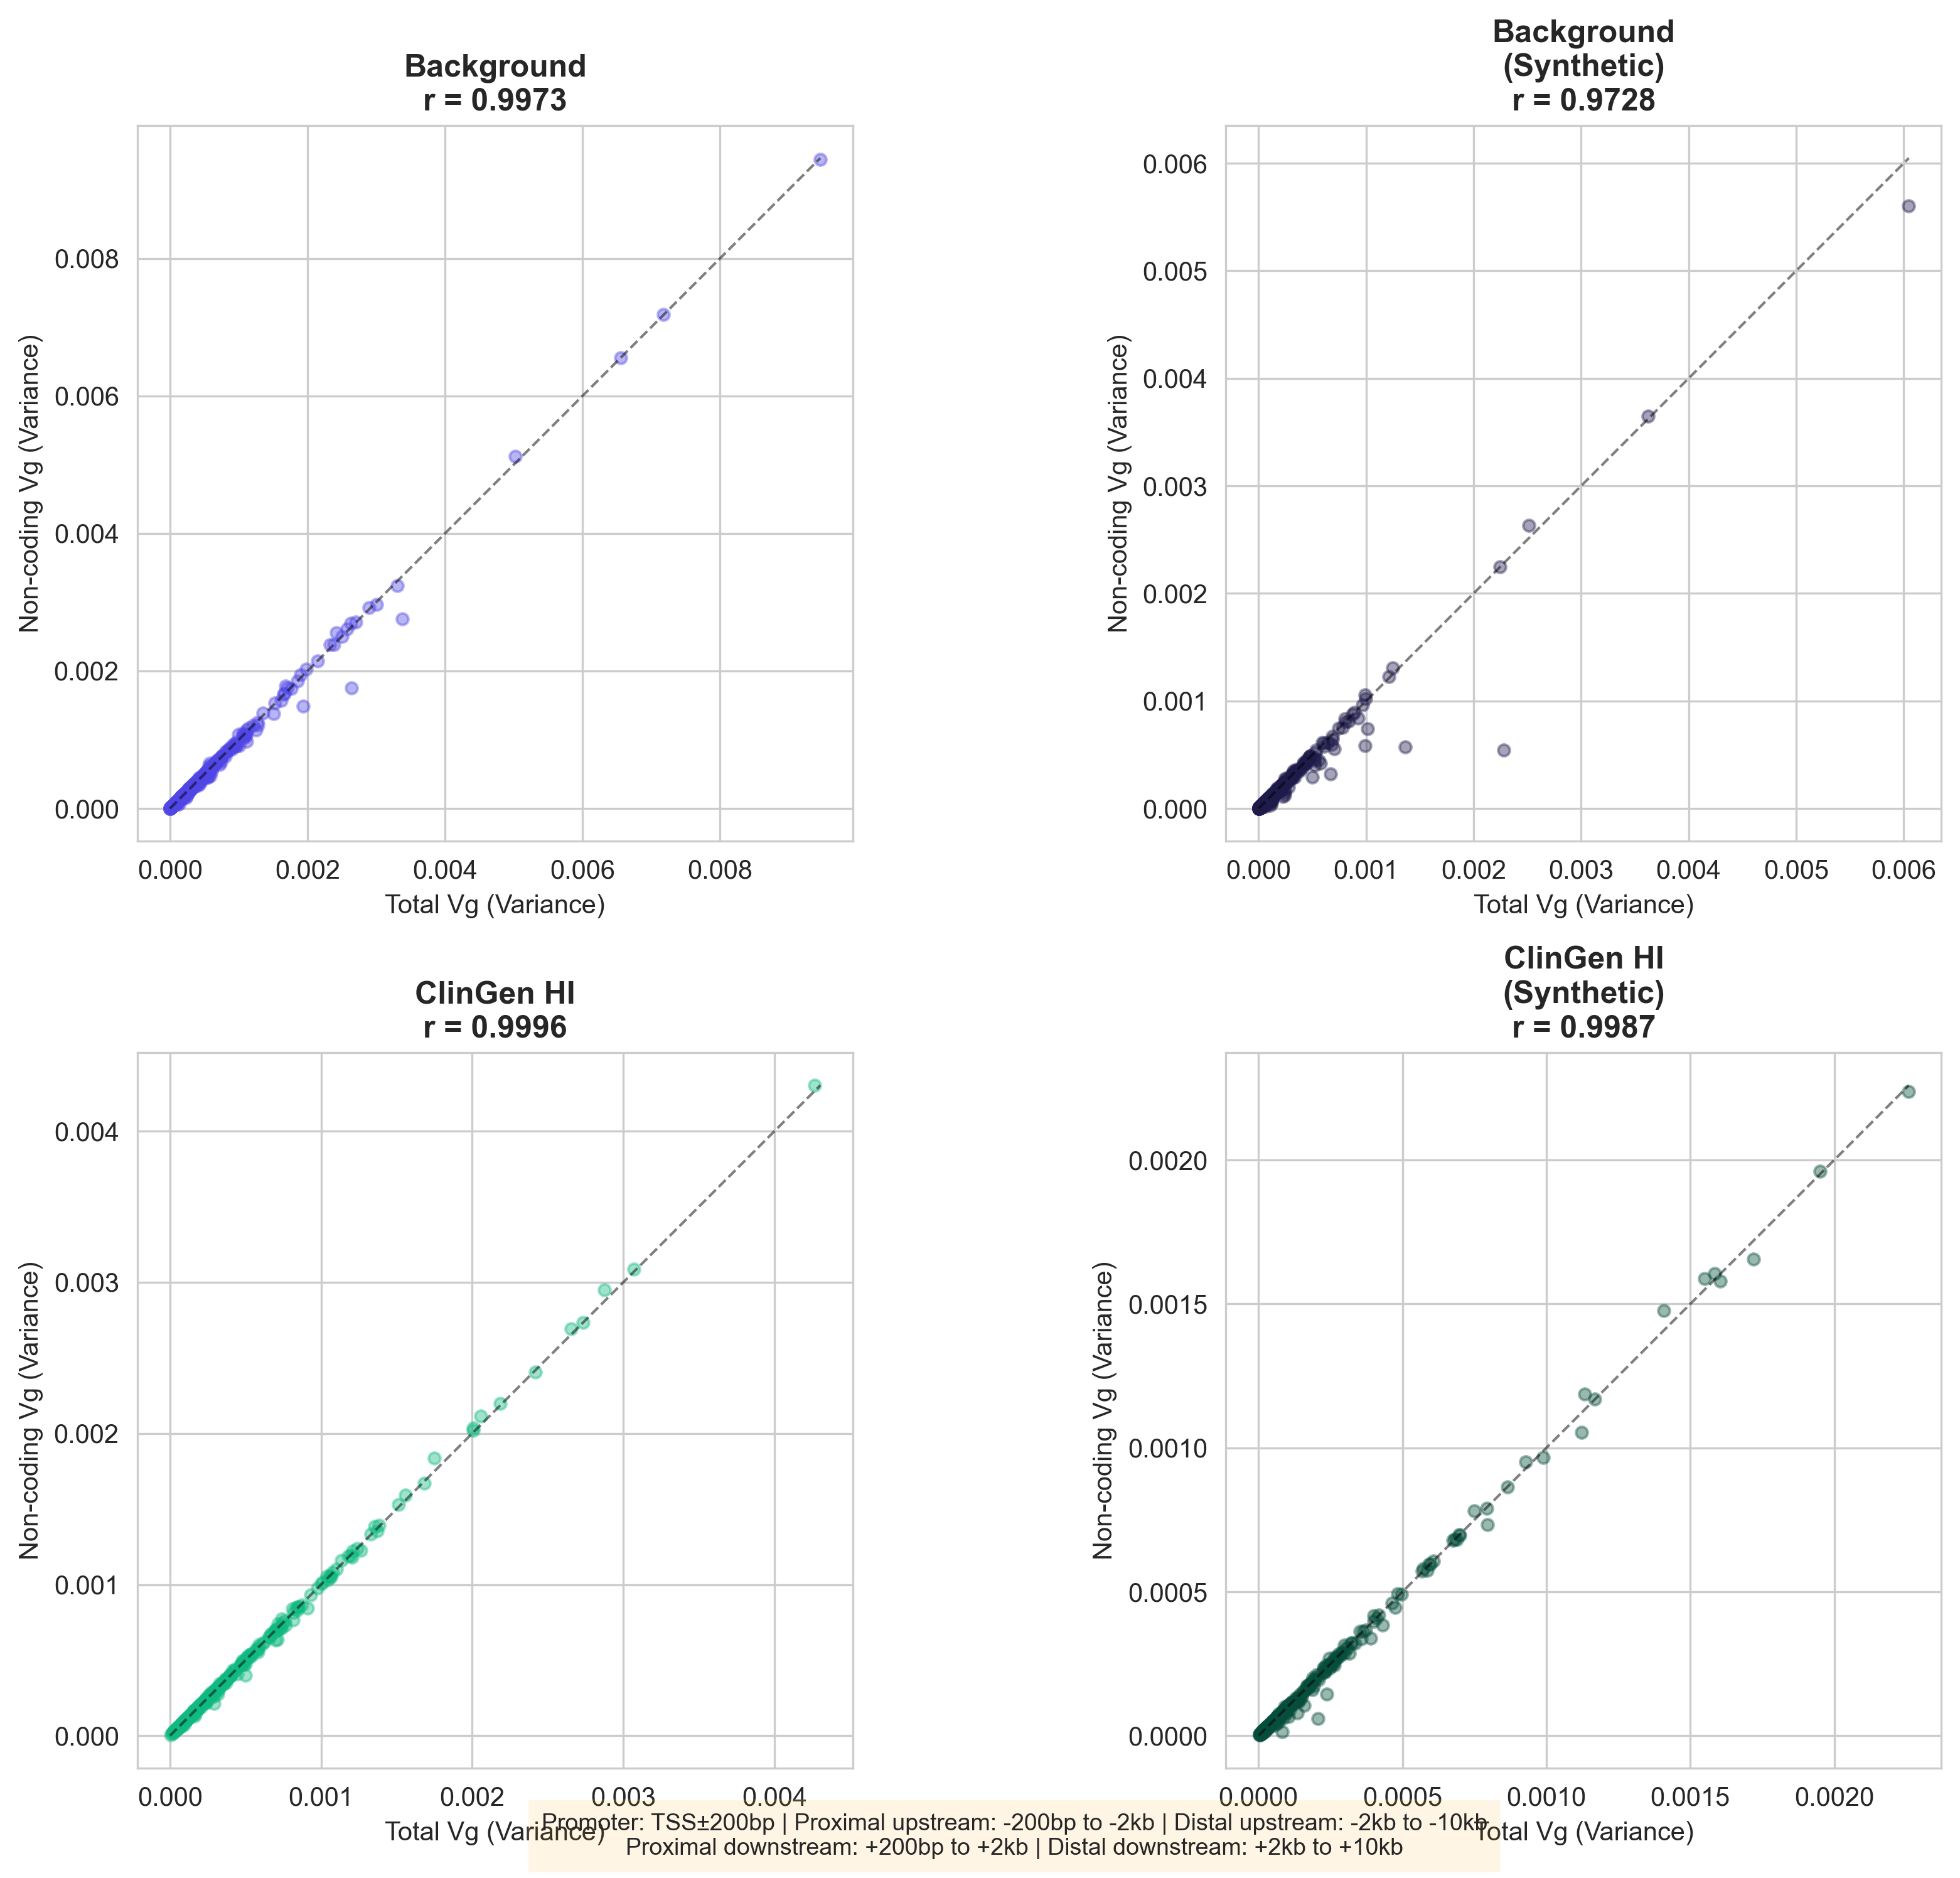

[save_plot] Saved: 03_Architectural_Redistribution_CDS_Impact_Scatter_18022026_1637.pdf
[save_plot] Saved: 03_Architectural_Redistribution_CDS_Impact_Scatter_18022026_1637.svg


<Figure size 1920x1440 with 0 Axes>

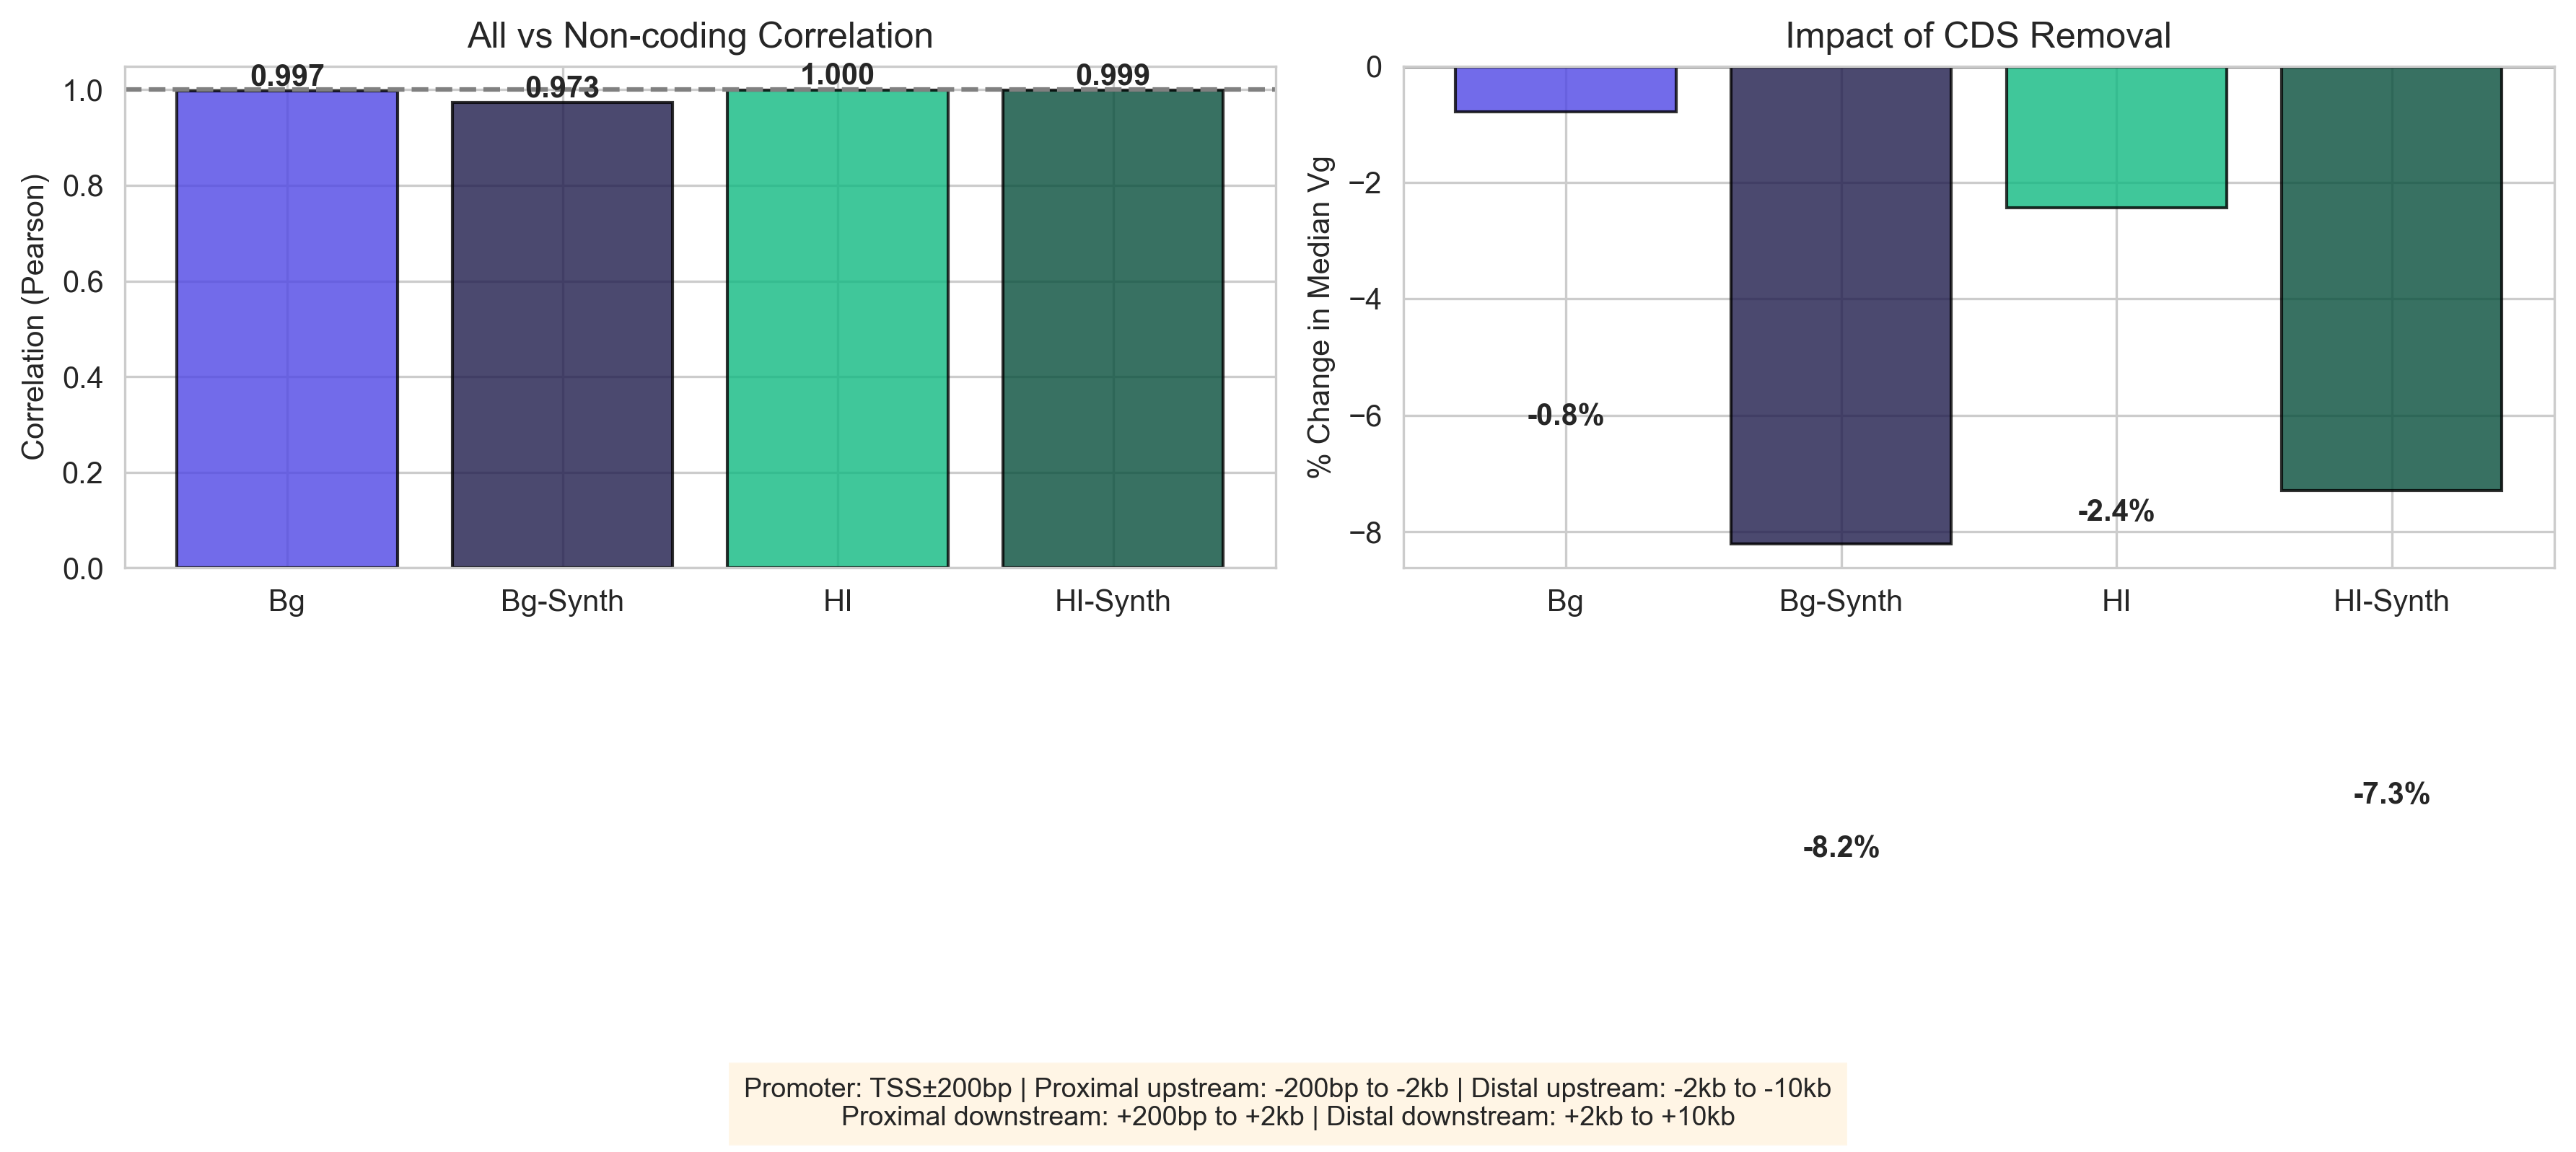

[save_plot] Saved: 03_Architectural_Redistribution_CDS_Impact_Summary_18022026_1637.pdf
[save_plot] Saved: 03_Architectural_Redistribution_CDS_Impact_Summary_18022026_1637.svg


<Figure size 1920x1440 with 0 Axes>

In [ ]:
plot_data = []
for r in comparison_results:
    key = r['dataset']
    df_valid = r['df_comp'].filter((pl.col('n_noncoding') > 1) & pl.col('vg_all').is_not_null() & pl.col('vg_noncoding').is_not_null())
    for row in df_valid.iter_rows(named=True):
        plot_data.append({
            'key': key, # Keep original key for lookup
            'display_name': DISPLAY_NAMES[key],
            'vg_all': row['vg_all'],
            'vg_noncoding': row['vg_noncoding']
        })

df_plot = pl.DataFrame(plot_data)
keys_ordered = ['background', 'background_null', 'clingen', 'clingen_null']

with autosave("CDS_Impact_Scatter", notebook=NOTEBOOK_NAME):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for ax, key in zip(axes.flatten(), keys_ordered):
        subset = df_plot.filter(pl.col('key') == key)
        x, y = subset['vg_all'].to_numpy(), subset['vg_noncoding'].to_numpy()

        # Use config palette and names
        color = SOURCE_PALETTE[key]
        name = DISPLAY_NAMES[key]

        ax.scatter(x, y, alpha=0.4, s=20, color=color, label=name)

        # Identity line
        limit = max(x.max(), y.max())
        ax.plot([0, limit], [0, limit], 'k--', alpha=0.5, lw=1)

        corr = np.corrcoef(x, y)[0, 1] if len(x) > 1 else 0
        ax.set_title(f'{name}\nr = {corr:.4f}', fontweight='bold')
        ax.set_xlabel('Total Vg (Variance)')
        ax.set_ylabel('Non-coding Vg (Variance)')
        ax.set_aspect('equal')

    plt.figtext(0.5, 0.01,
                "Promoter: TSS±200bp | Proximal upstream: -200bp to -2kb | Distal upstream: -2kb to -10kb\n"
                "Proximal downstream: +200bp to +2kb | Distal downstream: +2kb to +10kb",
                ha="center", fontsize=9, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})
    plt.tight_layout()
    plt.show()

with autosave("CDS_Impact_Summary", notebook=NOTEBOOK_NAME):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    summary_data = {r['dataset']: r for r in comparison_results}
    ordered_res = [summary_data[k] for k in keys_ordered if k in summary_data]

    x_labels = [DISPLAY_NAMES_SHORT[r['dataset']] for r in ordered_res]
    bar_colors = [SOURCE_PALETTE[r['dataset']] for r in ordered_res]

    # 1. Correlation Bar
    corrs = [r['corr'] for r in ordered_res]
    bars1 = ax1.bar(x_labels, corrs, color=bar_colors, edgecolor='black', alpha=0.8)
    ax1.axhline(1.0, color='gray', linestyle='--')
    ax1.set_ylabel('Correlation (Pearson)')
    ax1.set_title('All vs Non-coding Correlation')

    for rect in bars1:
        height = rect.get_height()
        ax1.text(rect.get_x() + rect.get_width()/2., height, f'{height:.3f}',
                 ha='center', va='bottom', fontweight='bold')

    # 2. % Change Bar
    pcts = [r['pct_change'] for r in ordered_res]
    bars2 = ax2.bar(x_labels, pcts, color=bar_colors, edgecolor='black', alpha=0.8)
    ax2.axhline(0, color='black', alpha=0.5)
    ax2.set_ylabel('% Change in Median Vg')
    ax2.set_title('Impact of CDS Removal')

    for rect in bars2:
        height = rect.get_height()
        y_pos = height if height > 0 else height - 5 # Adjust label position for negative bars
        va = 'bottom' if height > 0 else 'top'
        ax2.text(rect.get_x() + rect.get_width()/2., y_pos, f'{height:.1f}%',
                 ha='center', va=va, fontweight='bold')

    plt.figtext(0.5, -0.05,
                "Promoter: TSS±200bp | Proximal upstream: -200bp to -2kb | Distal upstream: -2kb to -10kb\n"
                "Proximal downstream: +200bp to +2kb | Distal downstream: +2kb to +10kb",
                ha="center", fontsize=9, bbox={"facecolor":"orange", "alpha":0.1, "pad":5})
    plt.tight_layout()
    plt.show()